In [59]:
import os

import cv2
import matplotlib.pyplot as plt

from astropy.stats import SigmaClip
from photutils.background import Background2D, MeanBackground, MedianBackground, ModeEstimatorBackground, MMMBackground, SExtractorBackground, BiweightLocationBackground


# Metrics

In [60]:
import numpy as np

def eval_all(groundtruth_mask, pred_mask):
    precision = precision_score_(groundtruth_mask, pred_mask)
    recall = recall_score_(groundtruth_mask, pred_mask)
    acc = accuracy(groundtruth_mask, pred_mask)
    dice = dice_coef(groundtruth_mask, pred_mask)
    iou_score = iou(groundtruth_mask, pred_mask)
    return precision, recall, acc, dice, iou_score

def precision_score_(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    total_pixel_pred = np.sum(pred_mask)
    precision = np.mean(intersect/total_pixel_pred)
    return round(precision, 3)

def recall_score_(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    total_pixel_truth = np.sum(groundtruth_mask)
    recall = np.mean(intersect/total_pixel_truth)
    return round(recall, 3)

def accuracy(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    union = np.sum(pred_mask) + np.sum(groundtruth_mask) - intersect
    xor = np.sum(groundtruth_mask==pred_mask)
    acc = np.mean(xor/(union + xor - intersect))
    return round(acc, 3)

def dice_coef(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    total_sum = np.sum(pred_mask) + np.sum(groundtruth_mask)
    dice = np.mean(2*intersect/total_sum)
    return round(dice, 3) #round up to 3 decimal places

def iou(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    union = np.sum(pred_mask) + np.sum(groundtruth_mask) - intersect
    iou = np.mean(intersect/union)
    return round(iou, 3)

# Mask Creating Algorithm

## Lab

In [83]:
def create_mask_lab(image: np.ndarray, bkg_estimator = MeanBackground()) -> np.ndarray:
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
    l_channel = lab[:, :, 0]
    sigma_clip = SigmaClip(sigma=3.0)
    bkg = Background2D(l_channel, (50, 50), filter_size=(3, 3), sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
    l_channel_bg = l_channel - bkg.background
    threshold = cv2.threshold(l_channel_bg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    threshold = cv2.morphologyEx(threshold, cv2.MORPH_OPEN, kernel, iterations=2)
    threshold = cv2.morphologyEx(threshold, cv2.MORPH_CLOSE, kernel, iterations=2)
    return threshold

### HSV

In [135]:
def create_mask_hsv(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_bound = np.array([0, 30, 30])
    upper_bound = np.array([179, 255, 255])
    mask = cv2.inRange(hsv, lower_bound, upper_bound)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    return mask

### Mean-Std

In [136]:
STD_DEVIATION_MULTIPLIER = 1.5
OPEN_ITERATIONS = 2
CLOSE_ITERATIONS = 2

def create_mask_mean_std(image: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
    a_channel = lab[:, :, 1]
    b_channel = lab[:, :, 2]
    
    a_channel = cv2.GaussianBlur(a_channel, (5, 5), 0)
    b_channel = cv2.GaussianBlur(b_channel, (5, 5), 0)
    
    med_a, std_a = np.median(a_channel), np.std(a_channel)
    med_b, std_b = np.median(b_channel), np.std(b_channel)
    a_thresholds = (
        med_a - STD_DEVIATION_MULTIPLIER * std_a,
        med_a + STD_DEVIATION_MULTIPLIER * std_a
    )
    b_thresholds = (
        med_b - STD_DEVIATION_MULTIPLIER * std_b,
        med_b + STD_DEVIATION_MULTIPLIER * std_b
    )
    
    bg_mask_a = cv2.inRange(a_channel, *a_thresholds)
    bg_mask_b = cv2.inRange(b_channel, *b_thresholds)
    
    fg_mask_a = cv2.bitwise_not(bg_mask_a)
    fg_mask_b = cv2.bitwise_not(bg_mask_b)
    
    h, w = image.shape[:2]
    kernel_size = max(5, min(h // 100, w // 100))  # Auto-adjust based on image size
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))

    for mask in [fg_mask_a, fg_mask_b]:
        cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, 
                        dst=mask, iterations=OPEN_ITERATIONS)
        cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, 
                        dst=mask, iterations=CLOSE_ITERATIONS)
    
    fg_mask_combined = cv2.bitwise_or(fg_mask_a, fg_mask_b)
    return fg_mask_combined

# Main

## New

In [ ]:

input_dir = os.path.join(os.getcwd(), 'Input')
input_names = os.listdir(input_dir)

for name in input_names:
    image = cv2.imread(os.path.join(input_dir, name))
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
    l_channel = lab[:, :, 0]
    sigma_clip = SigmaClip(sigma=3.0)
    bkg_mean = Background2D(l_channel, (50, 50), filter_size=(3, 3), sigma_clip=sigma_clip, bkg_estimator=MeanBackground())
    l_channel_bg = l_channel - bkg_mean.background
    
    new_image = cv2.merge([l_channel_bg, lab[:, :, 1], lab[:, :, 2]])
    new_image = cv2.cvtColor(new_image, cv2.COLOR_Lab2BGR)
    
    fig, axs = plt.subplots(1, 5, figsize=(15, 5))
    axs[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), axs[0].set_title('Original')
    axs[1].imshow(l_channel, cmap='gray'), axs[1].set_title('Original')
    axs[2].imshow(bkg_mean.background, cmap='gray'), axs[2].set_title('Background')
    axs[3].imshow(l_channel_bg, cmap='gray'), axs[3].set_title('Background Removed')
    axs[4].imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)), axs[4].set_title('New Image')
    
    plt.show()

In [84]:
def get_dir(folder_name):
    return os.path.join(os.getcwd(), folder_name)

def get_eval_dict():
    return {
        'precision': 0,
        'recall': 0,
        'accuracy': 0,
        'dice': 0,
        'iou': 0
    }
    
def check_name_match(name1, name2):
    if name1[:3] in ['5CY', 'LPY', 'NGG']:
        return name1[:6] == name2[:6]
    return name1[:4] == name2[:4]

def read_image(directory, name, in_gray=False):
    if in_gray:
        return cv2.imread(os.path.join(directory, name), cv2.IMREAD_GRAYSCALE)
    return cv2.imread(os.path.join(directory, name))

def apply_mask(image, mask):
    return cv2.bitwise_and(image, image, mask=mask)

def normalize_mask(mask):
    return mask / 255

def get_evaluation(groundtruth_mask, pred_mask):
    eval_dict = get_eval_dict()
    eval_dict['precision'], eval_dict['recall'], eval_dict['accuracy'], eval_dict['dice'], eval_dict['iou'] = eval_all(groundtruth_mask, pred_mask)
    return eval_dict

def update_total_eval(total_eval, eval_dict):
    for key in total_eval.keys():
        total_eval[key] += eval_dict[key]
    return total_eval

def calculate_average_from_total(total_eval, num_images):
    for key in total_eval.keys():
        total_eval[key] = round(total_eval[key] / num_images, 3)
    return total_eval

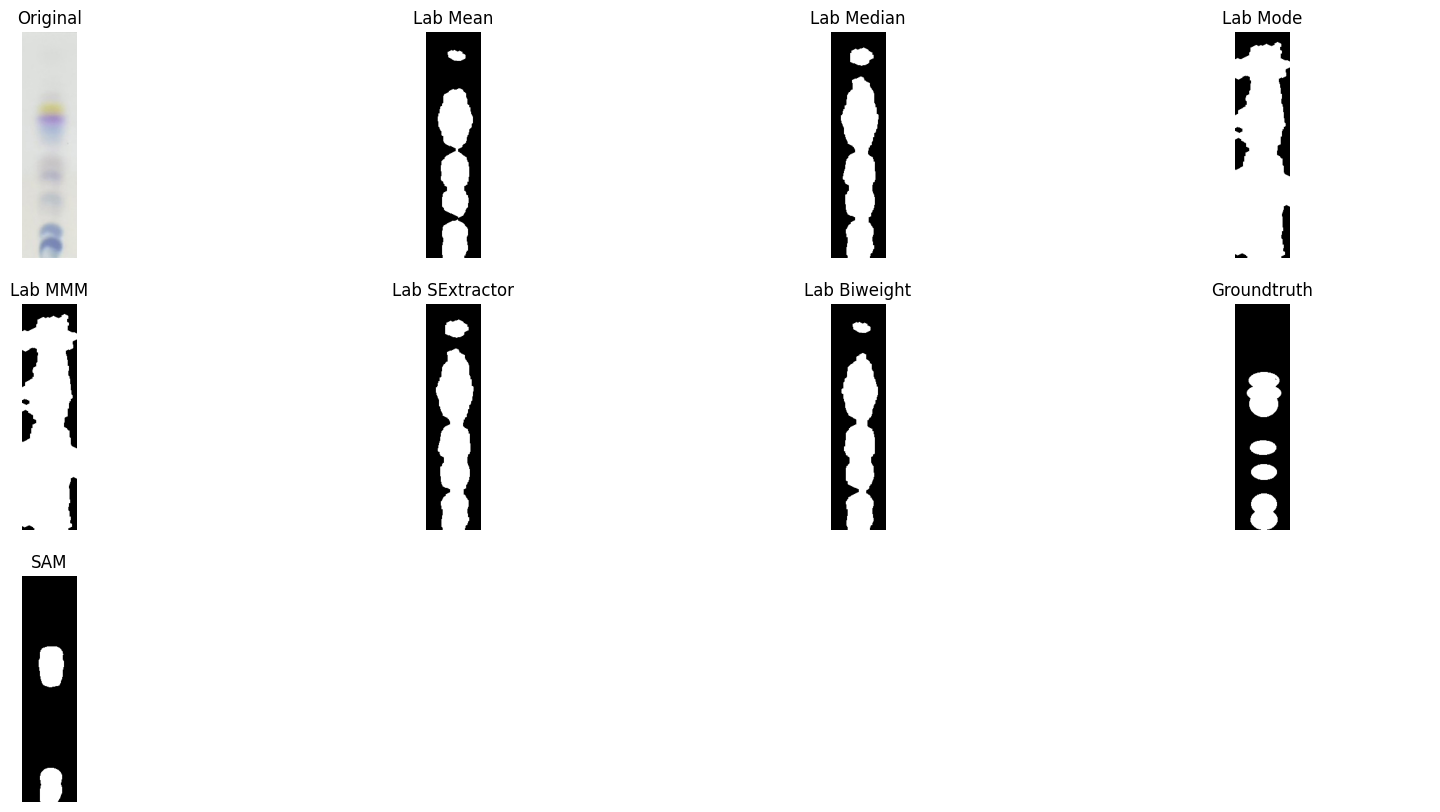

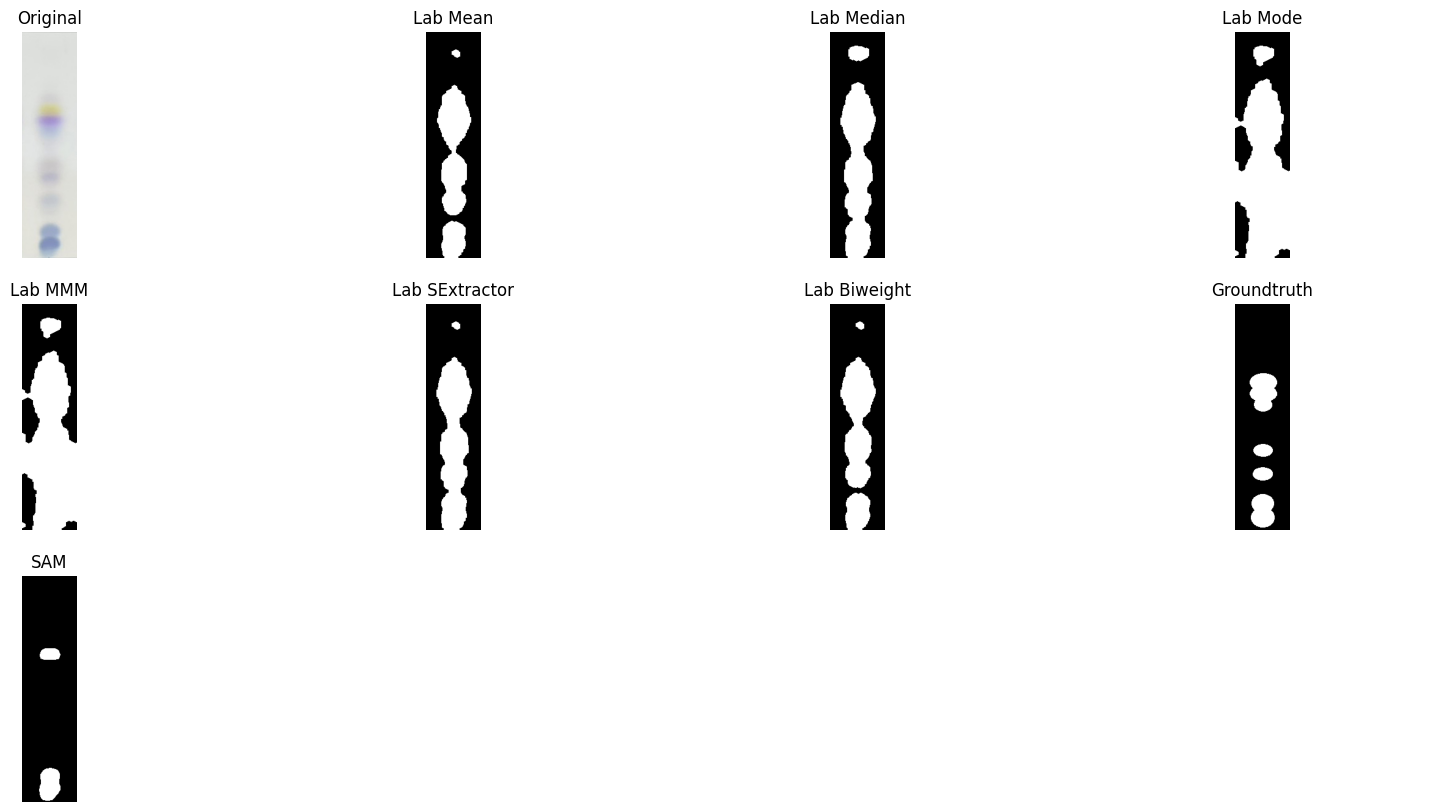

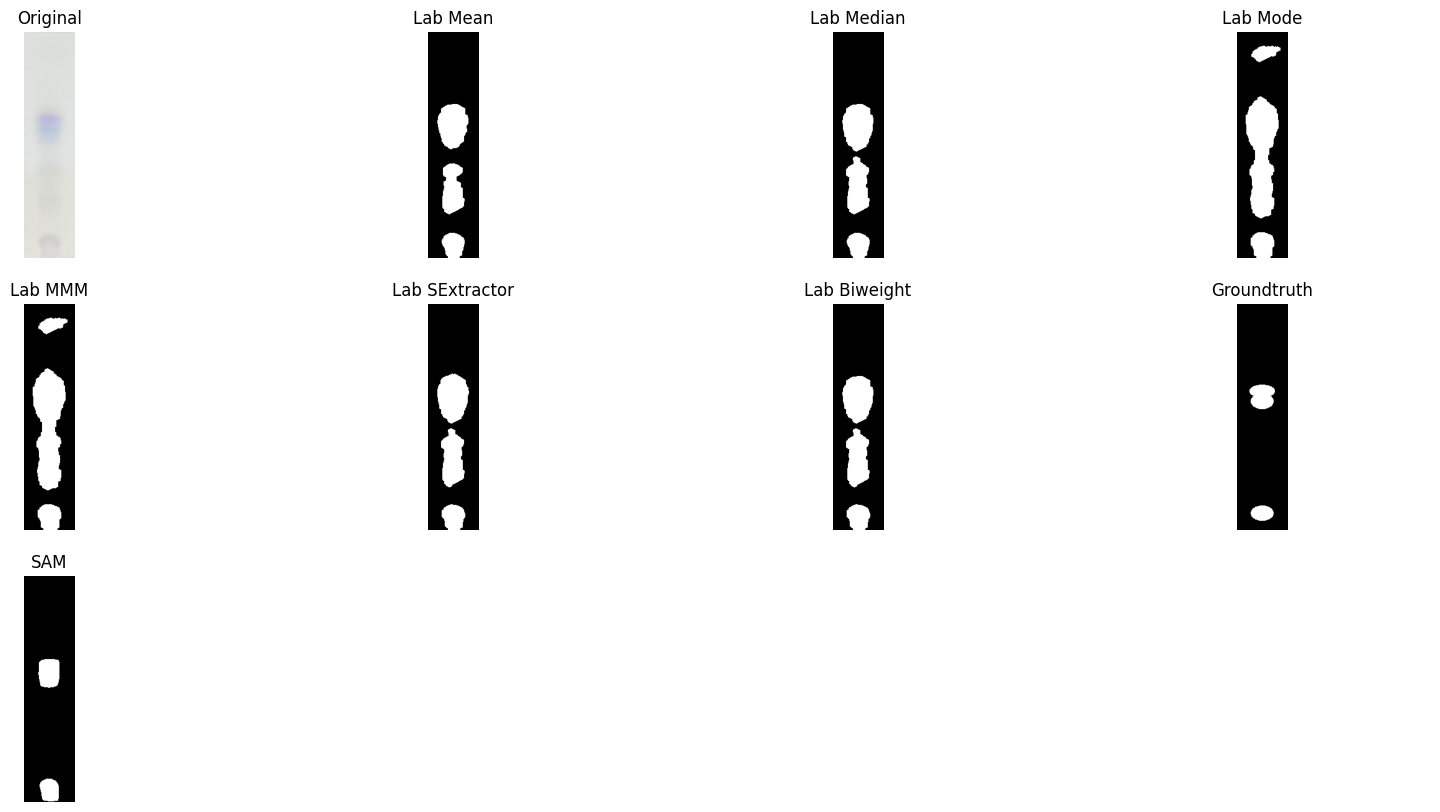

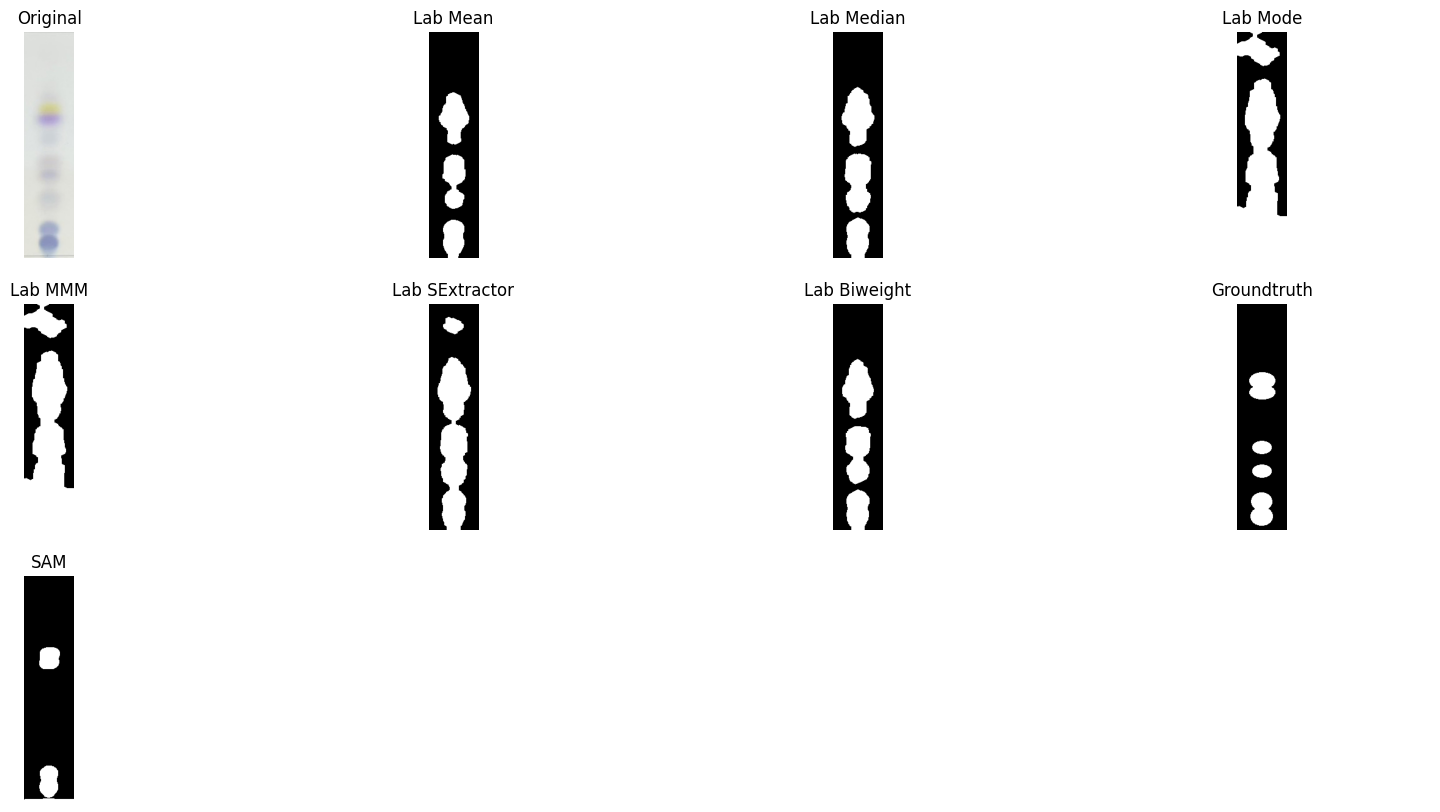

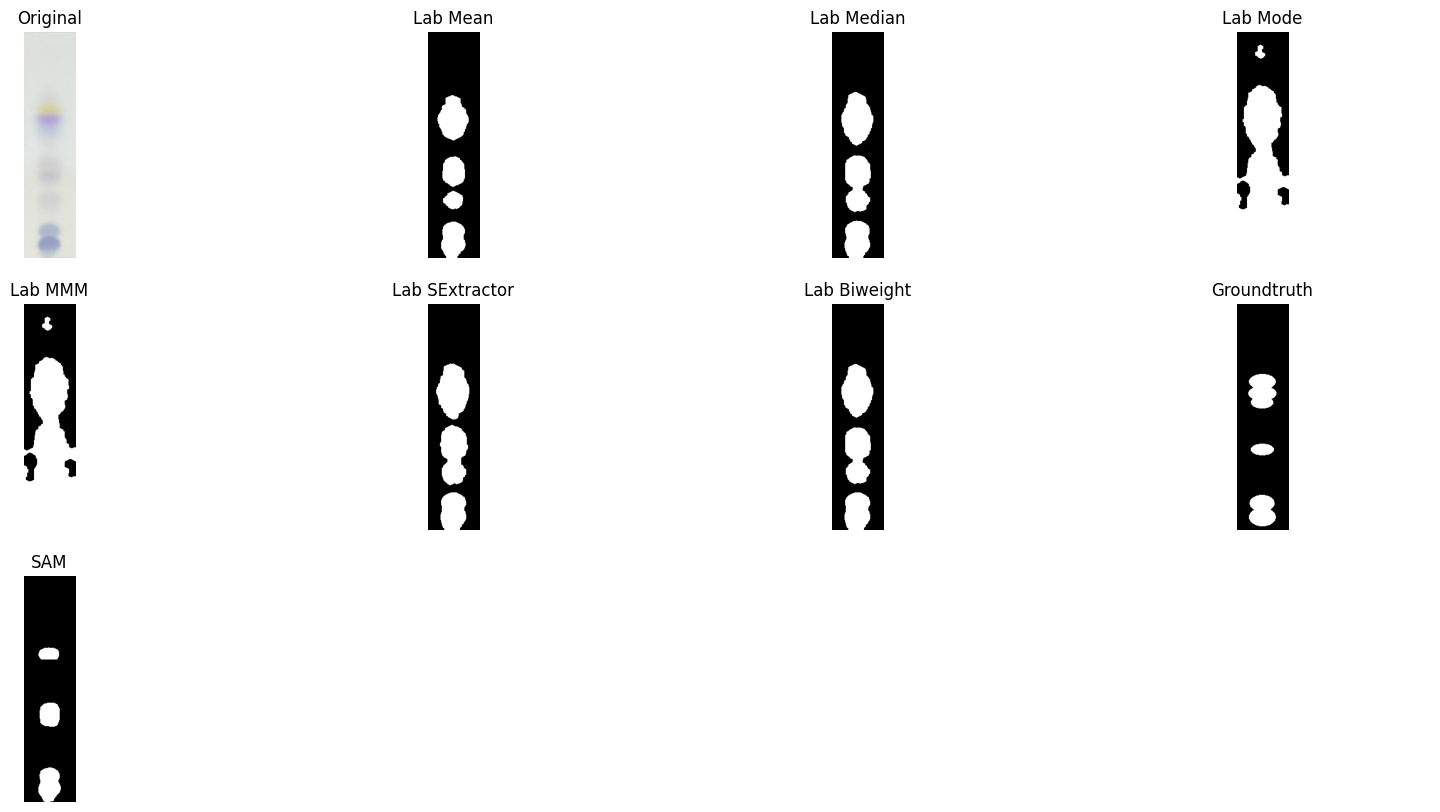

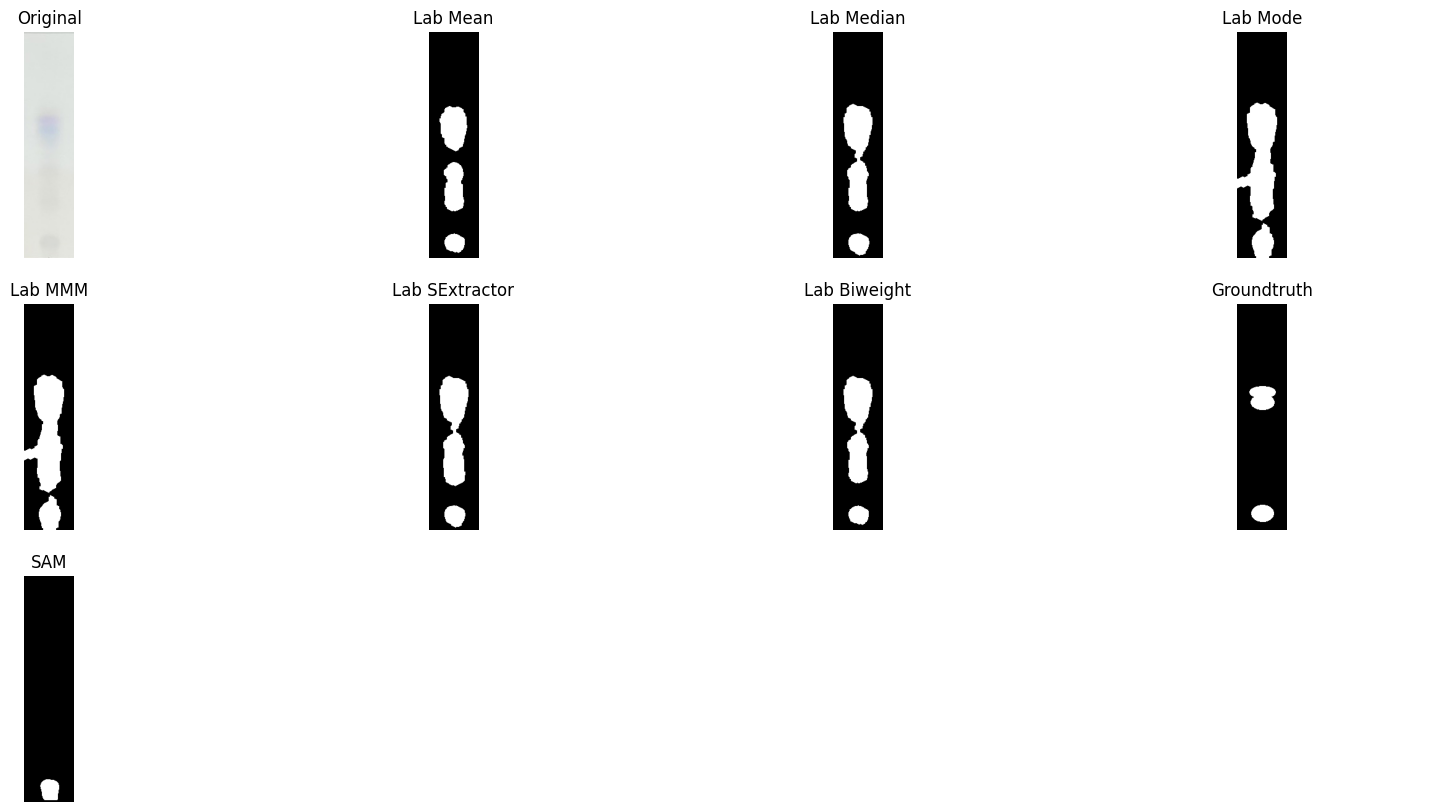

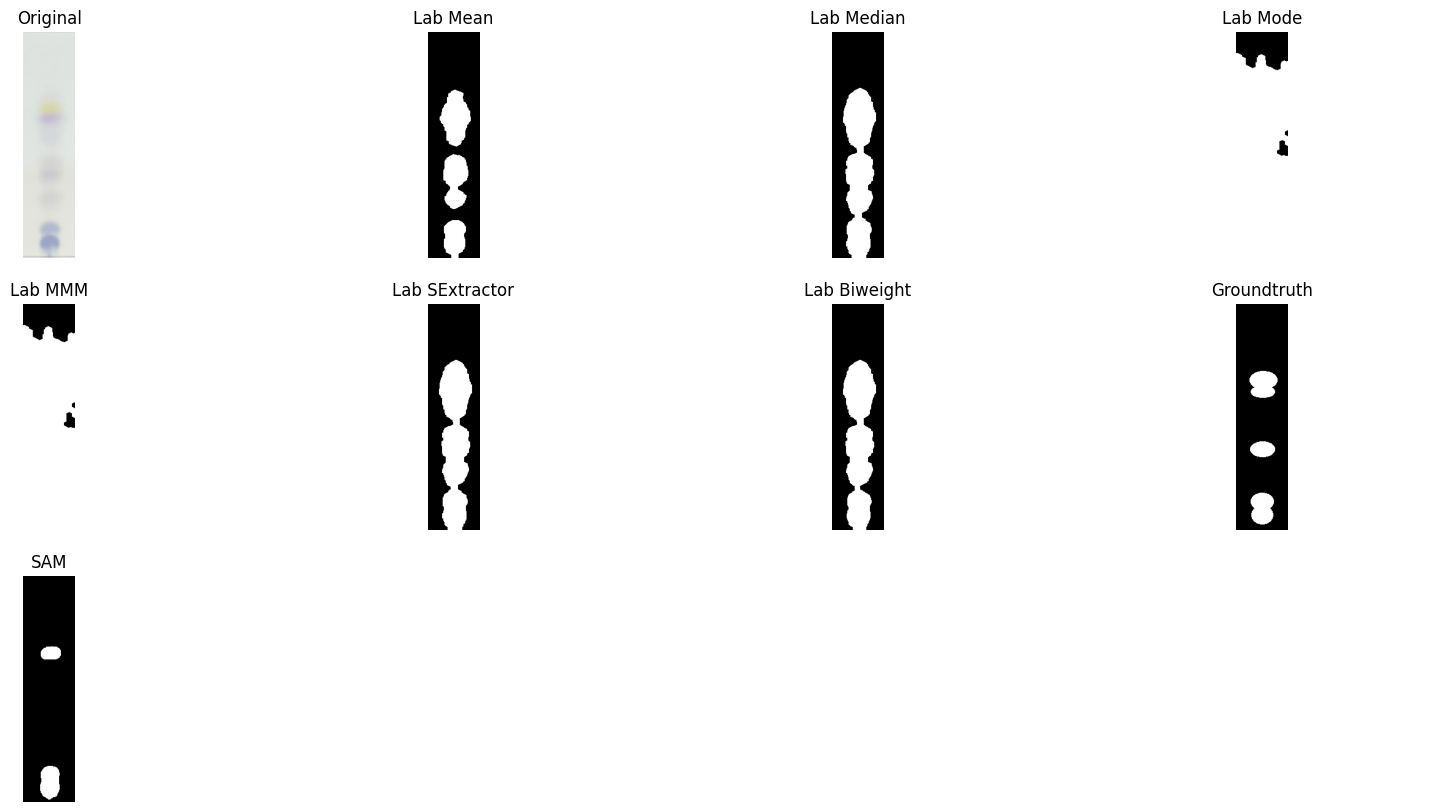

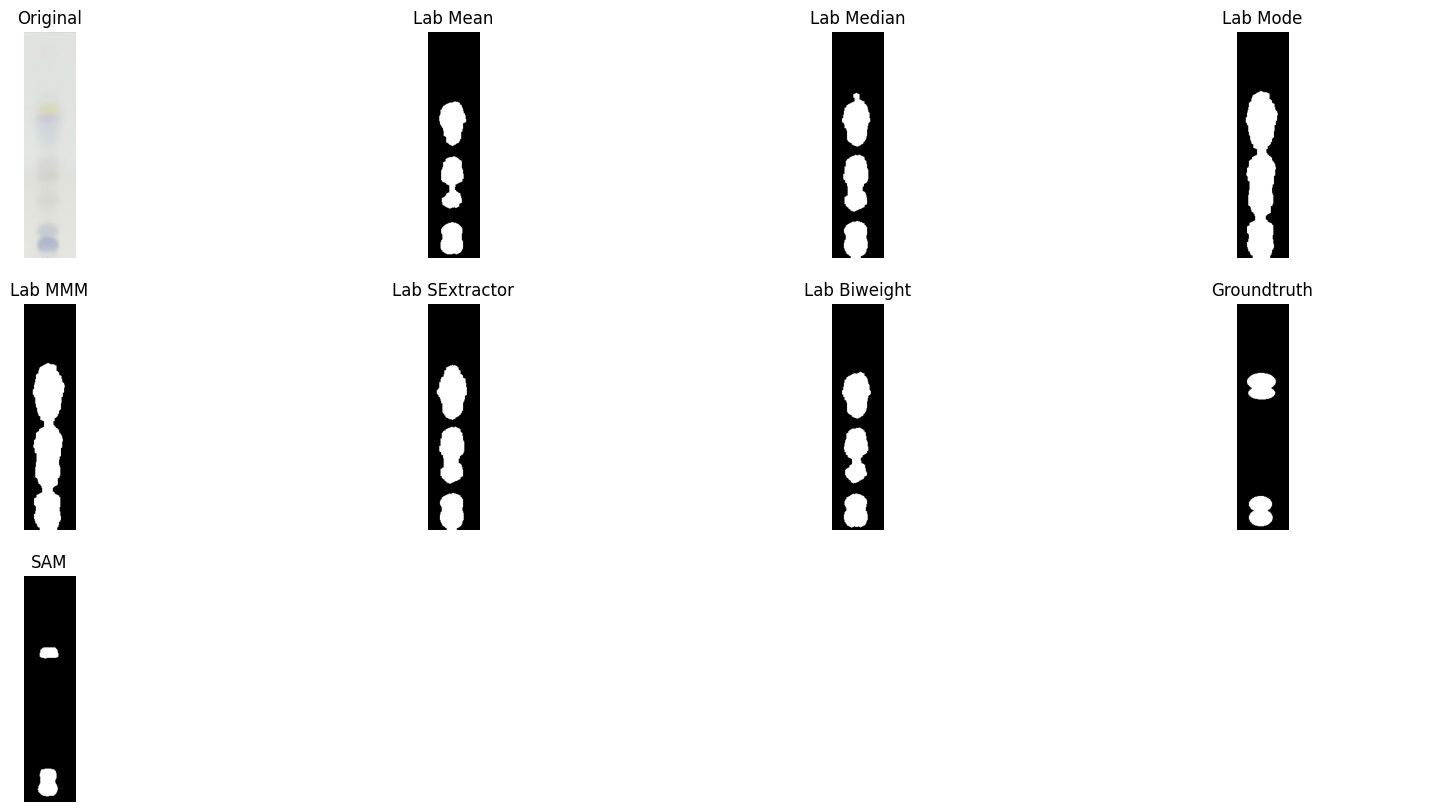

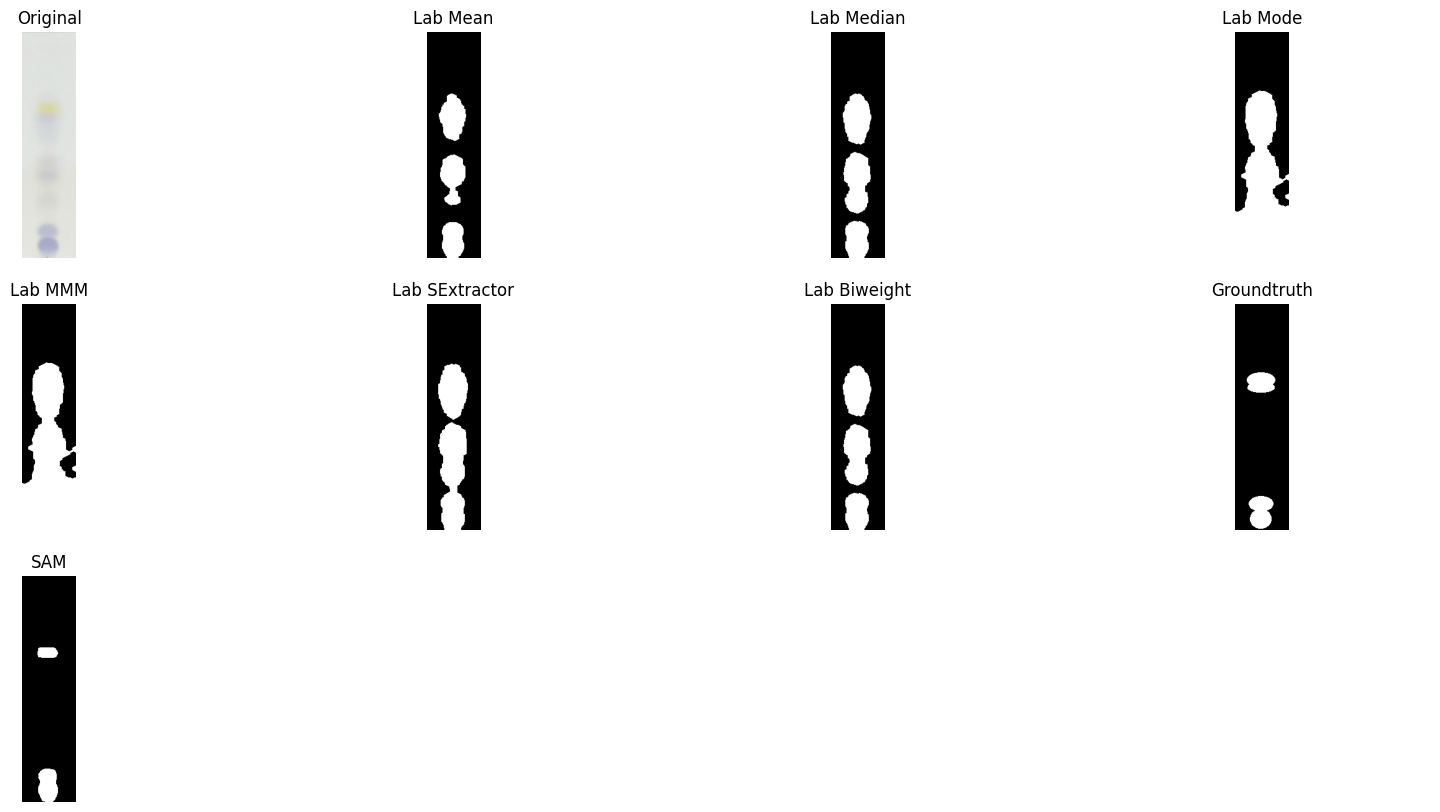

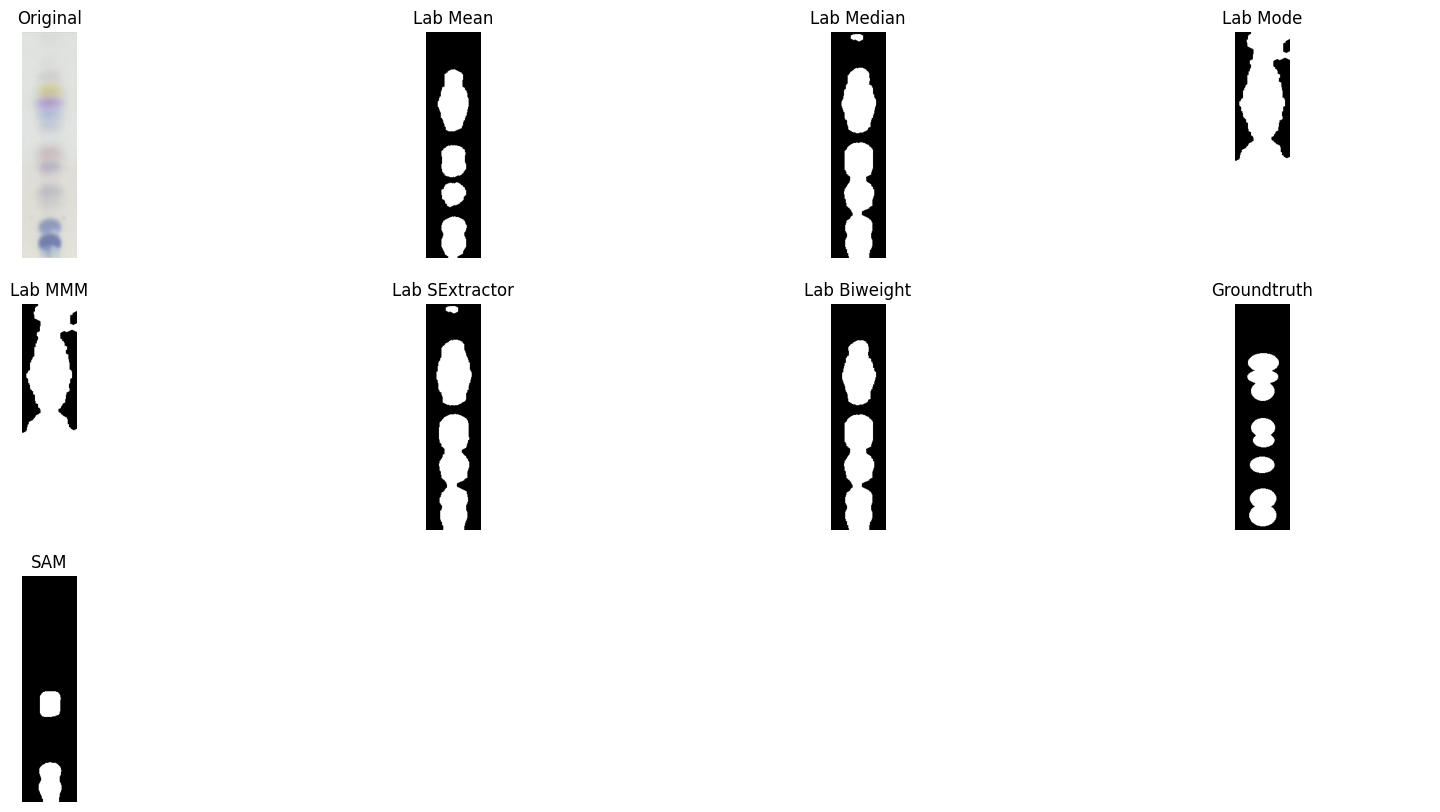

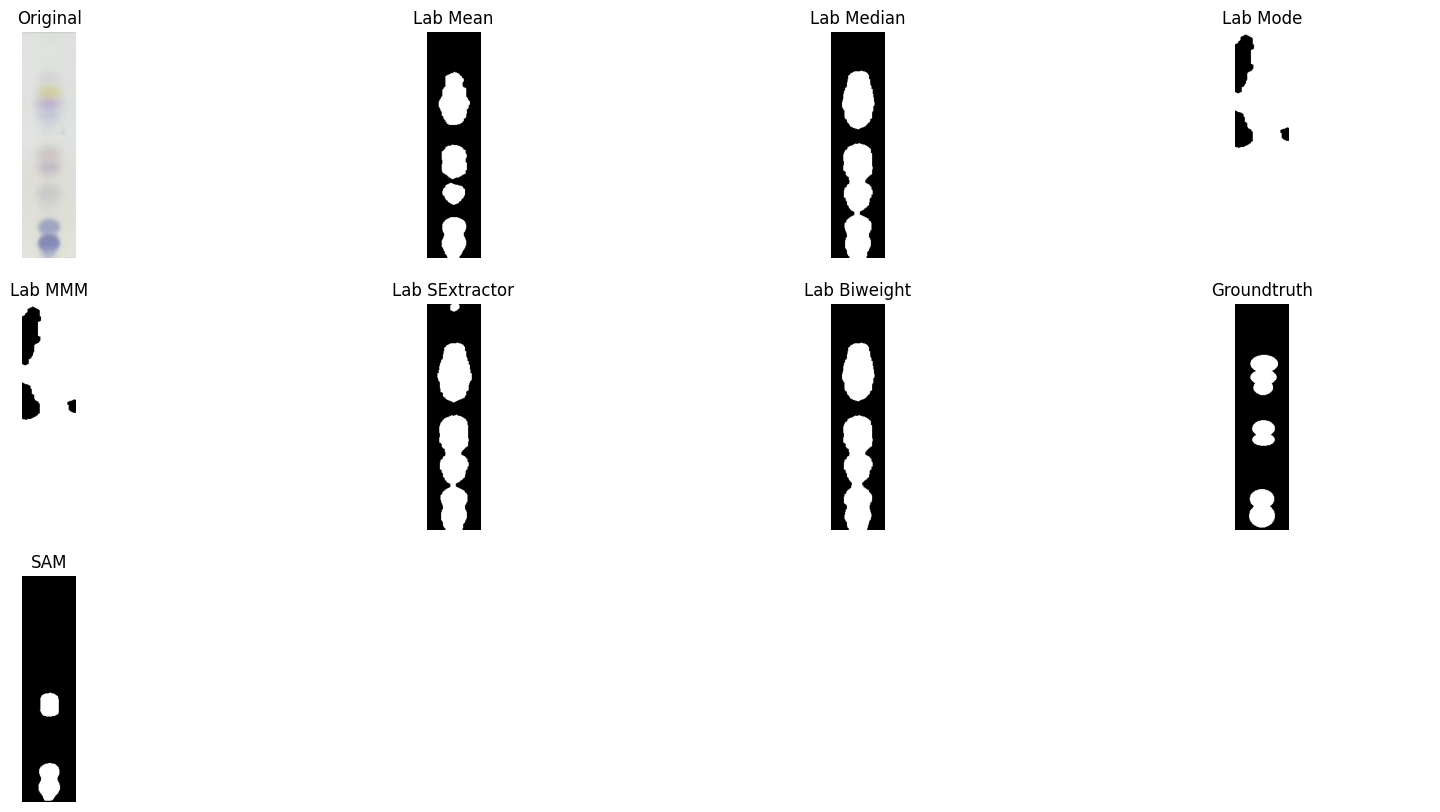

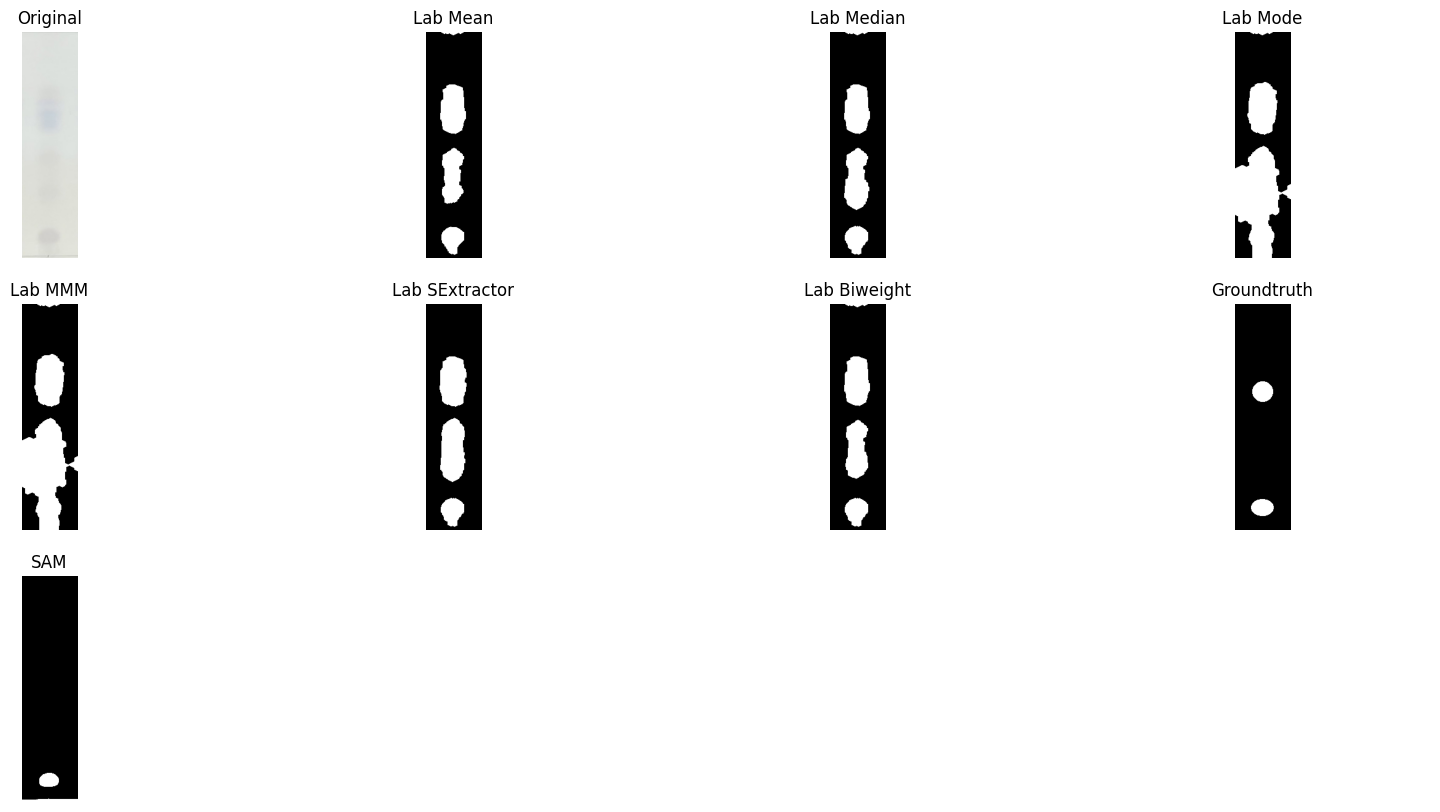

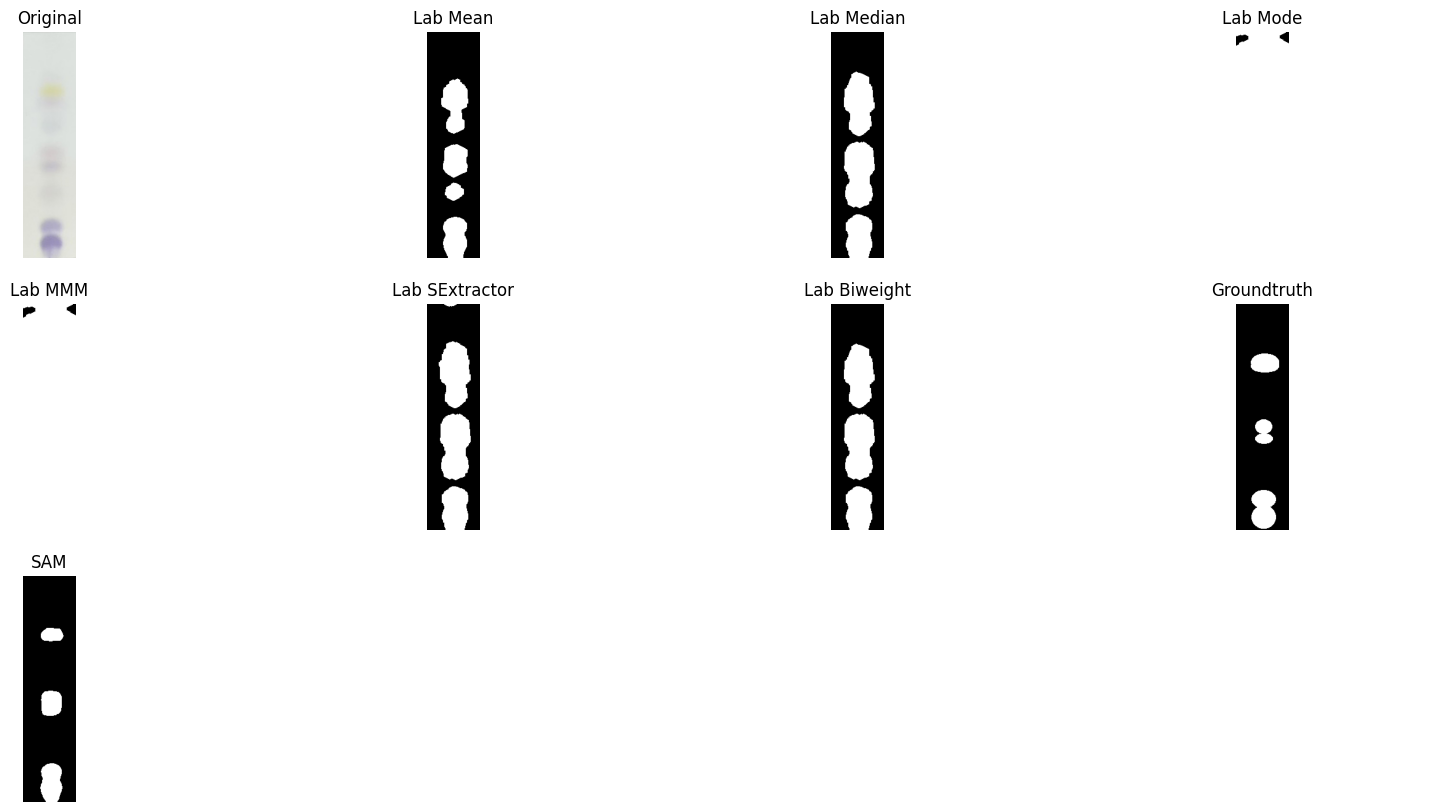

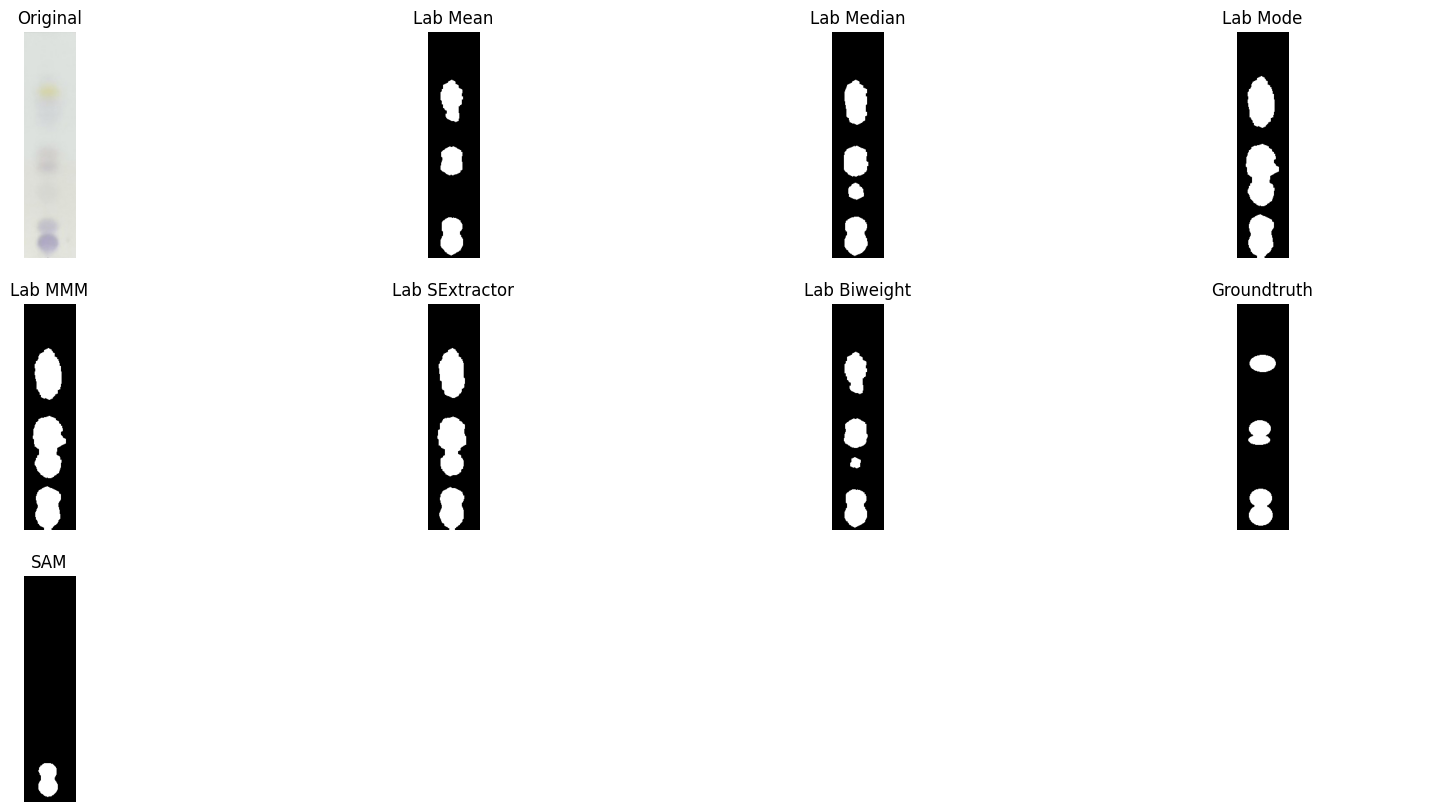

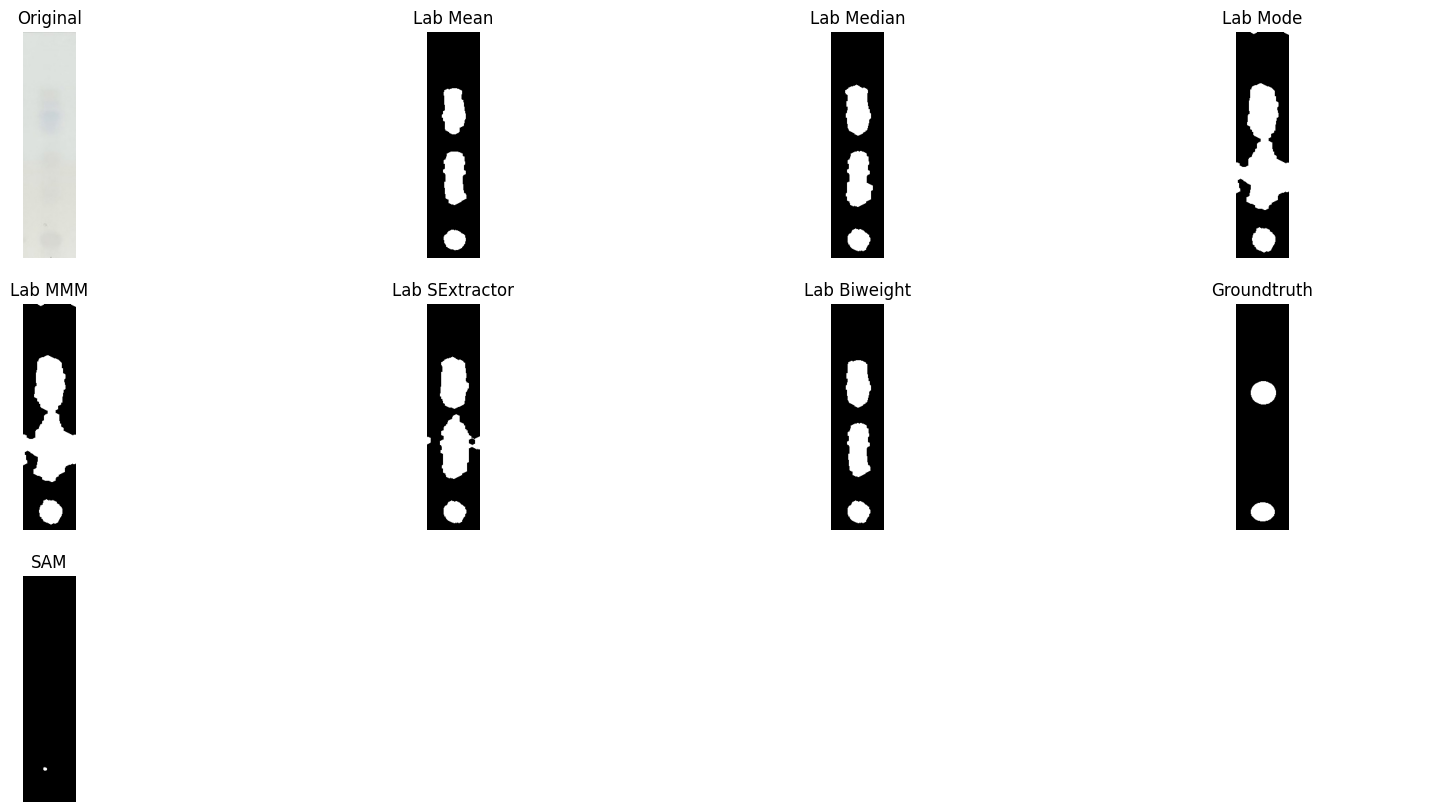

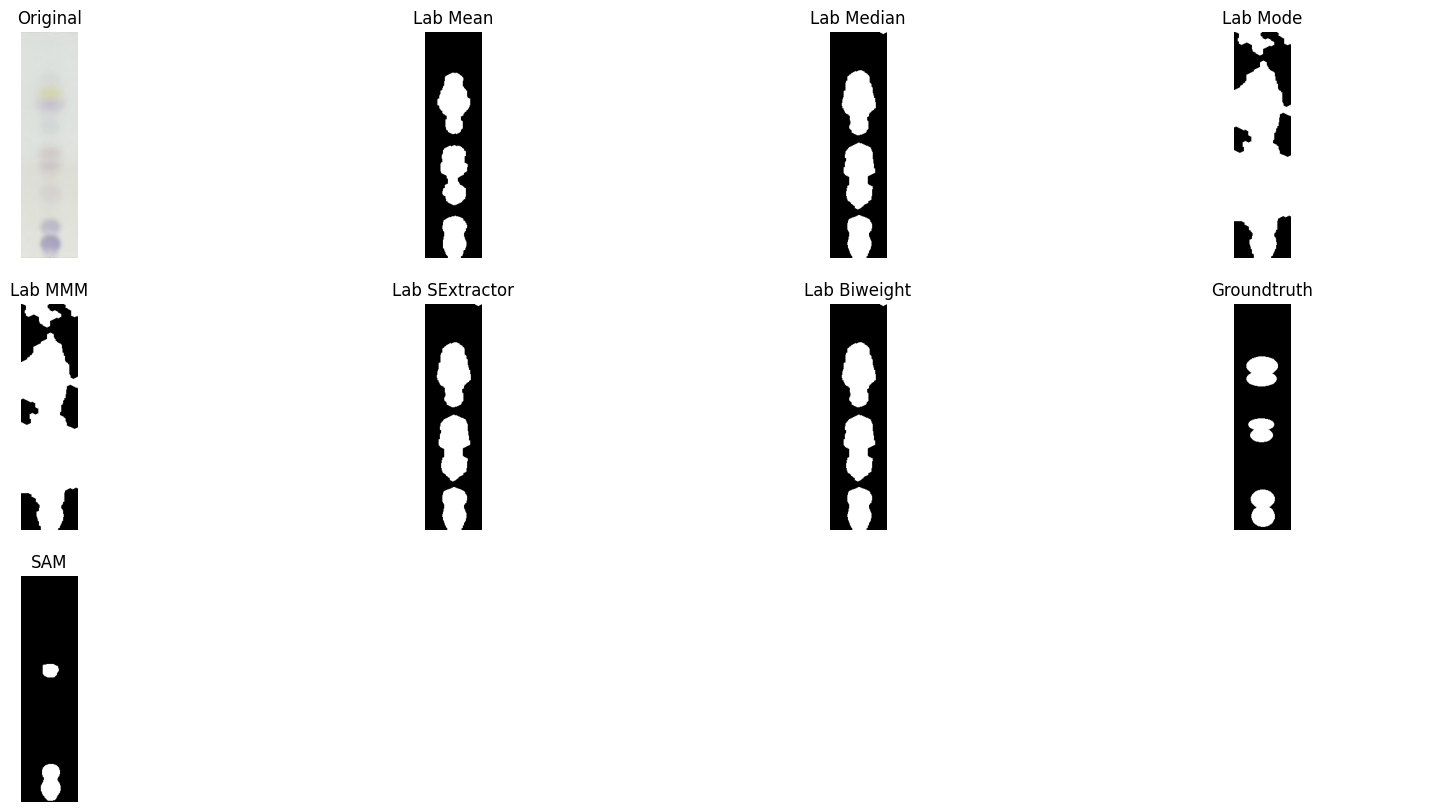

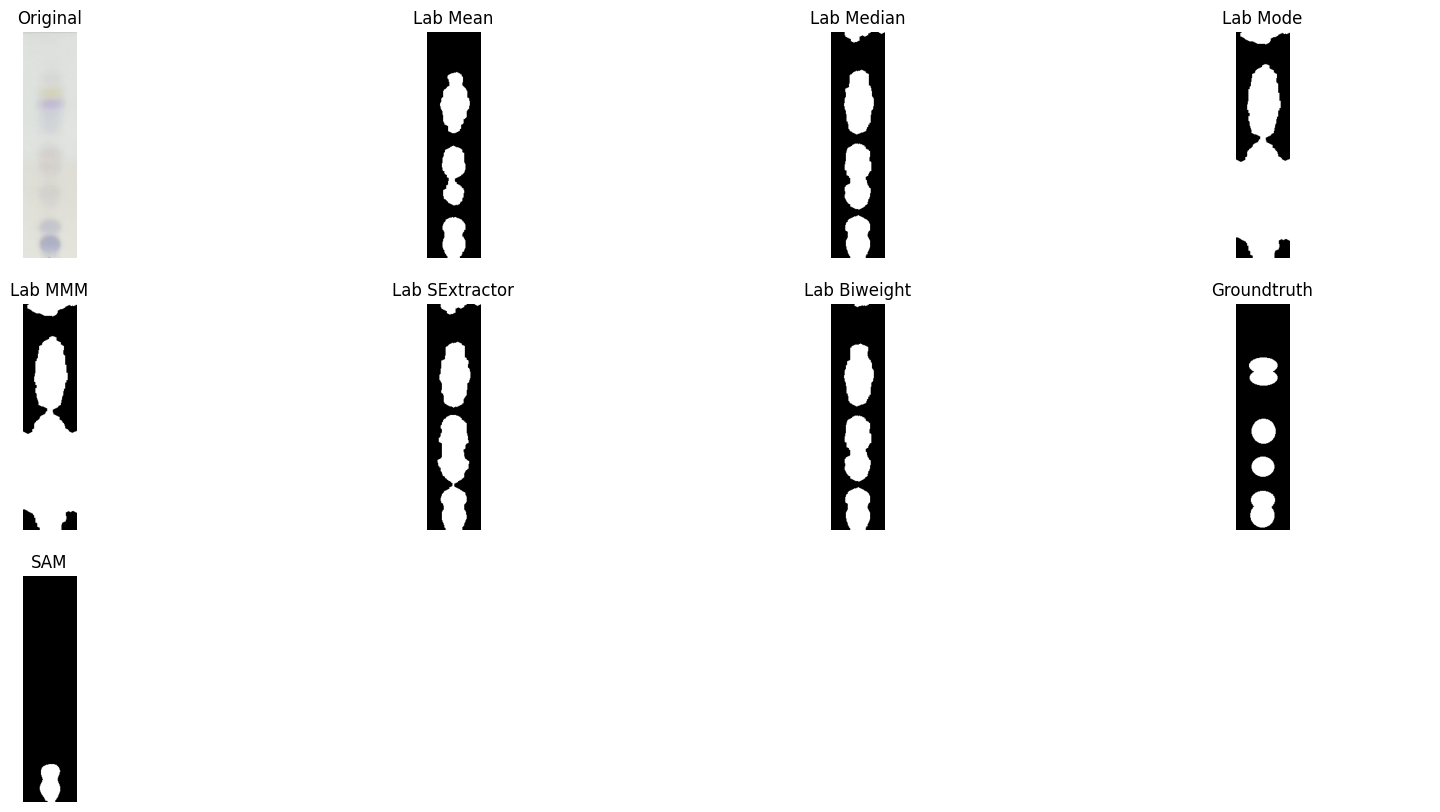

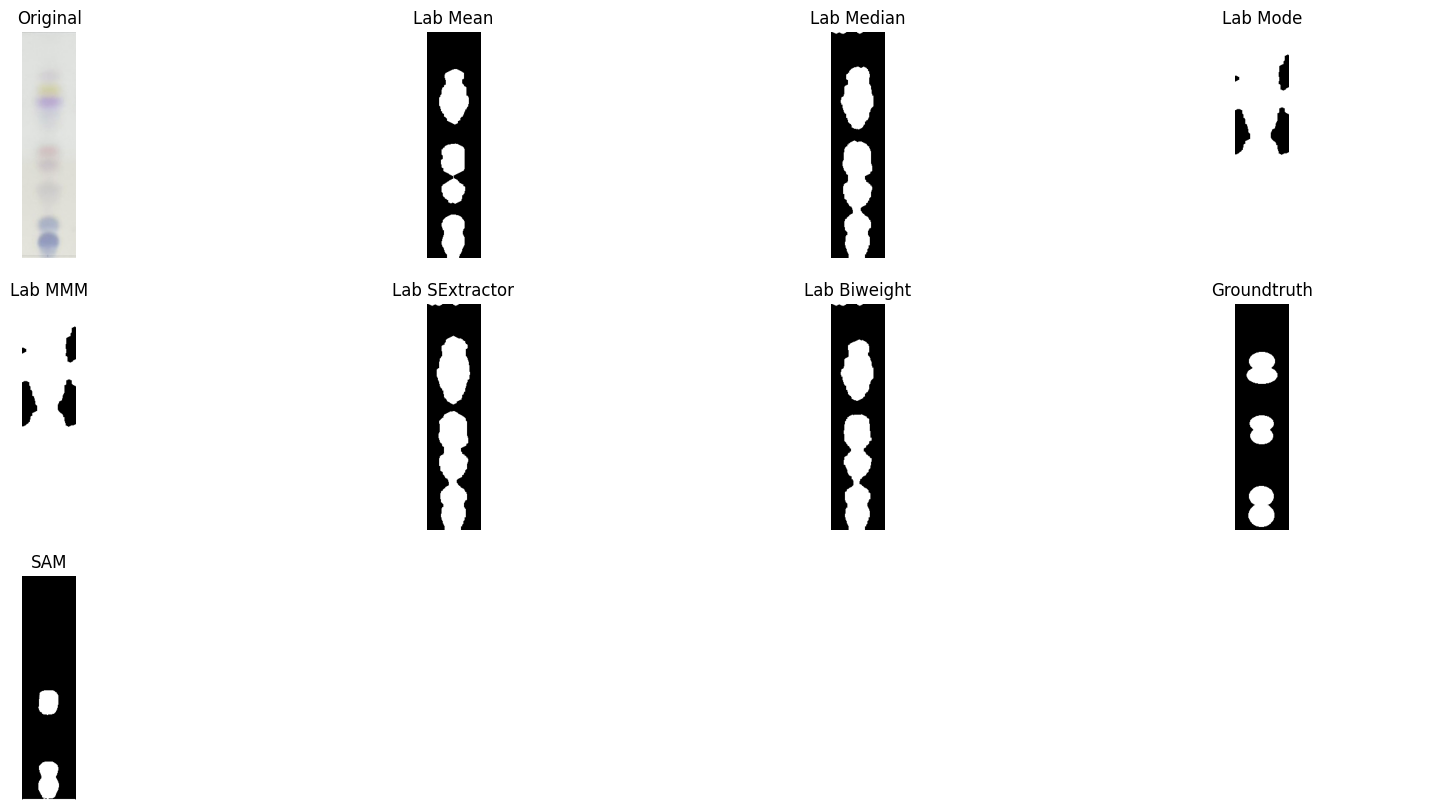

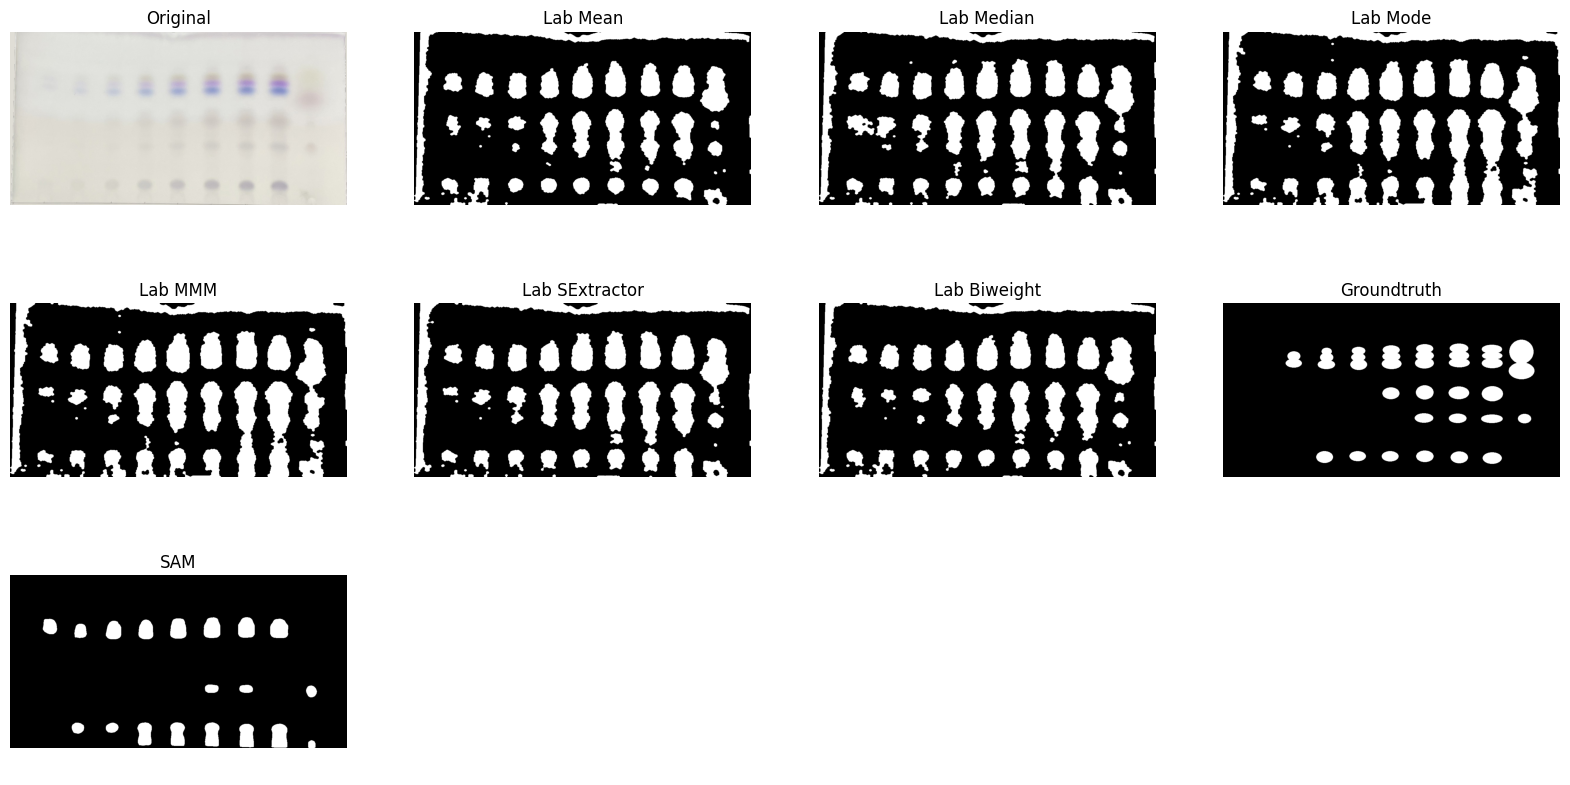

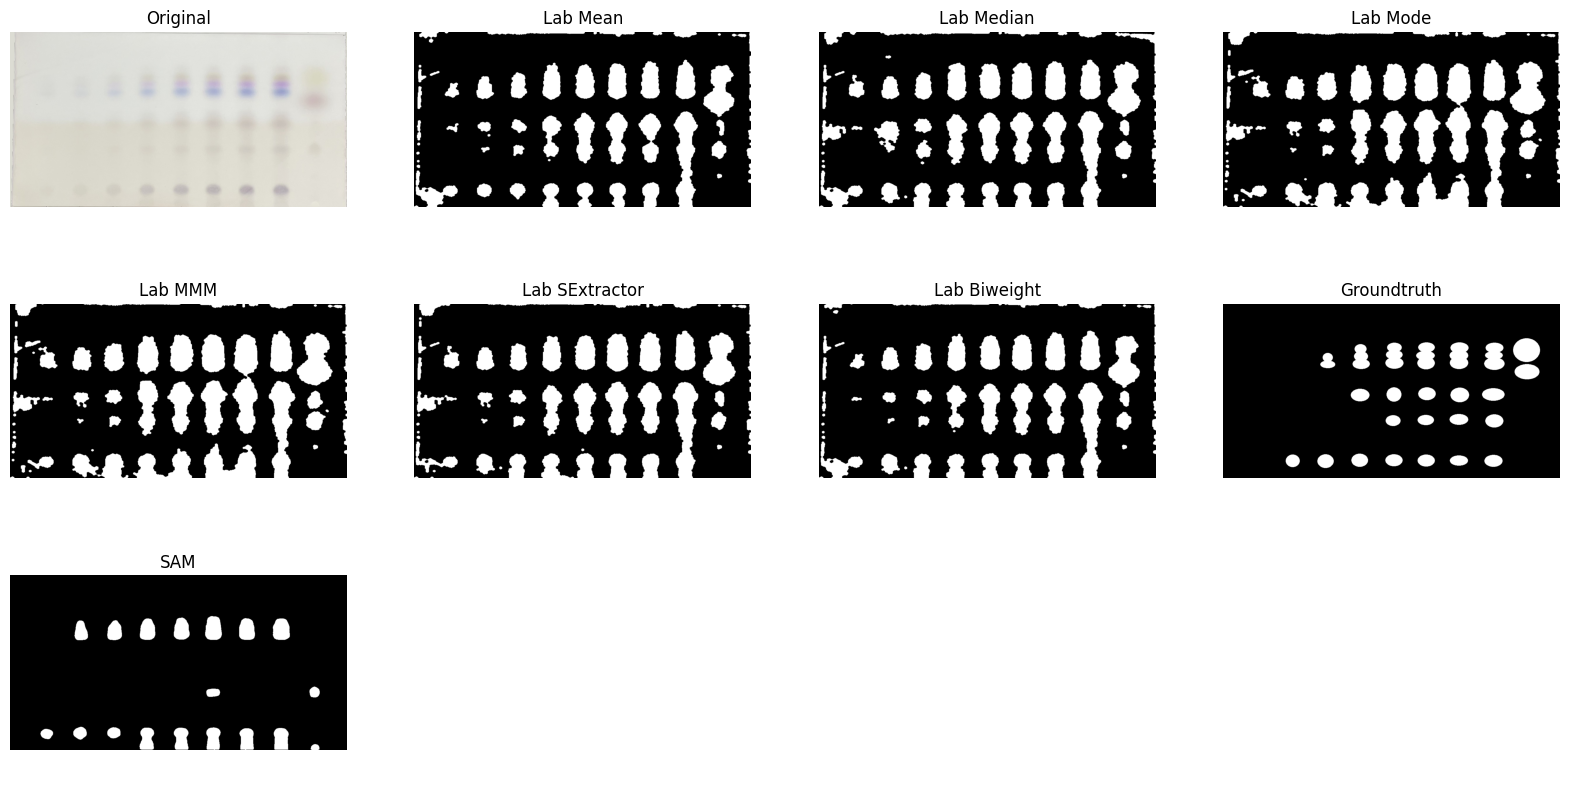

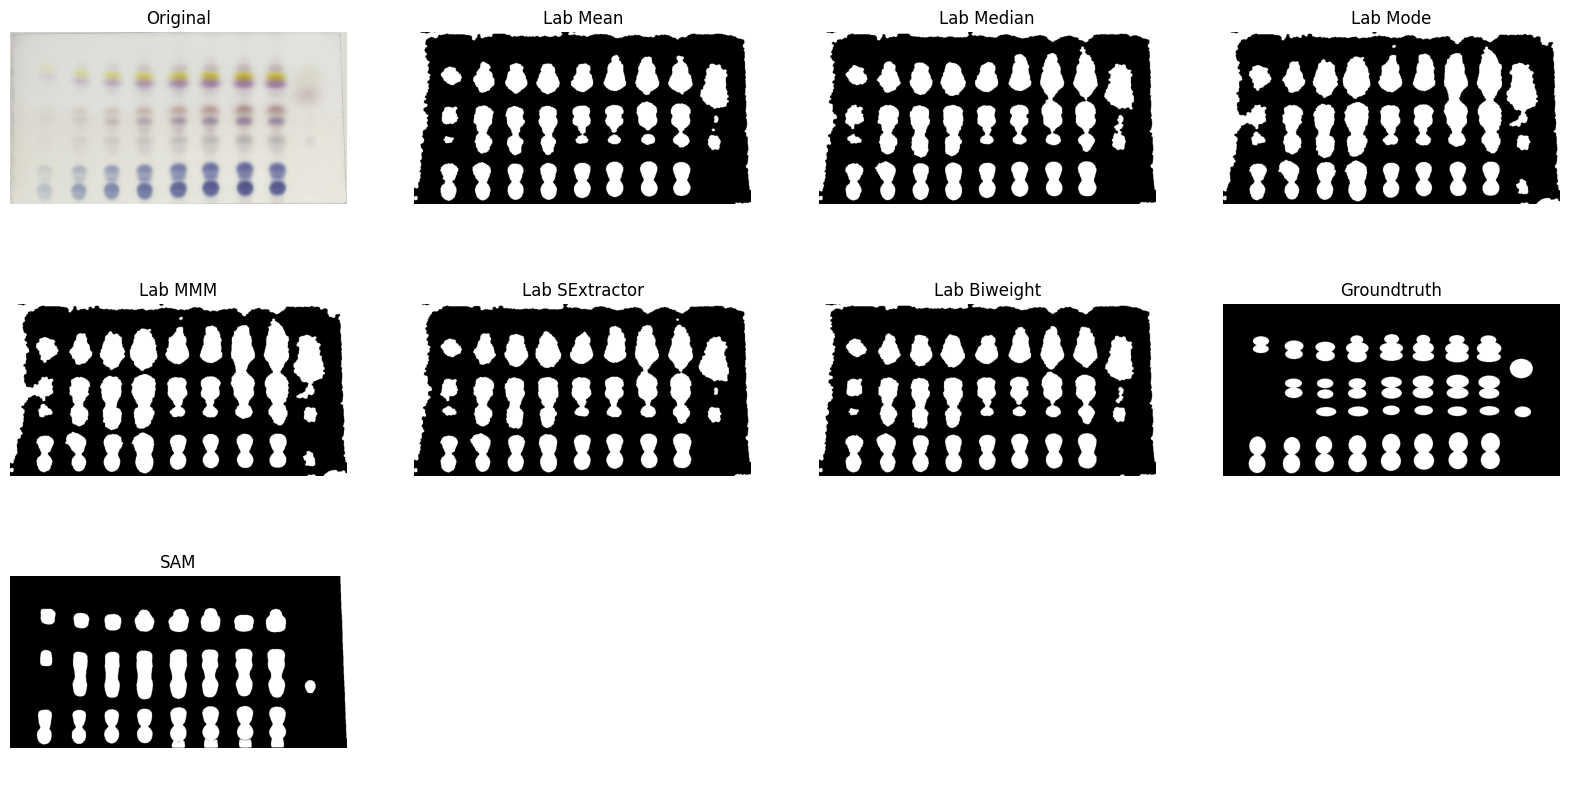

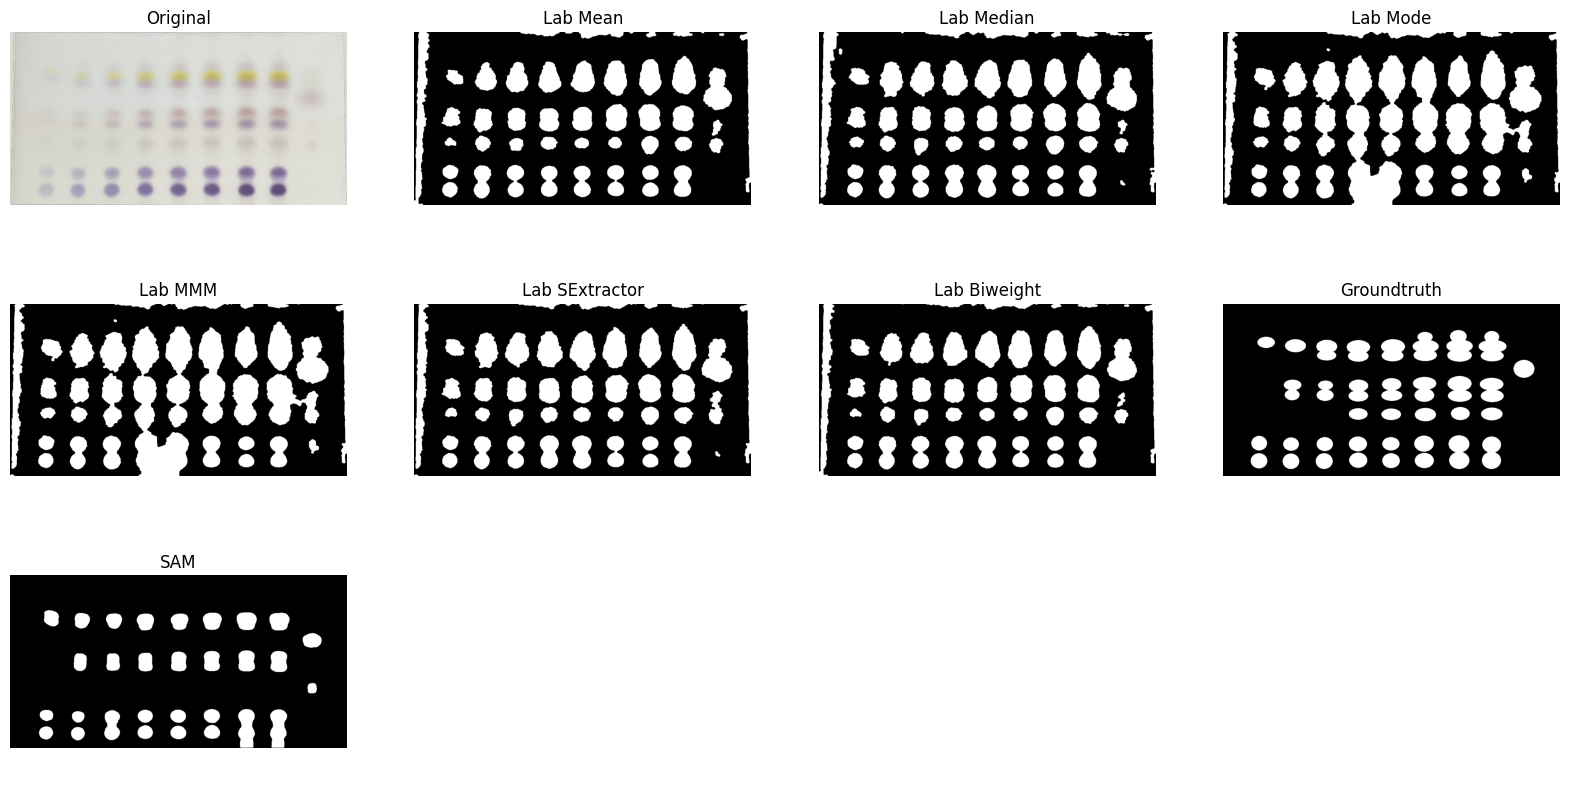

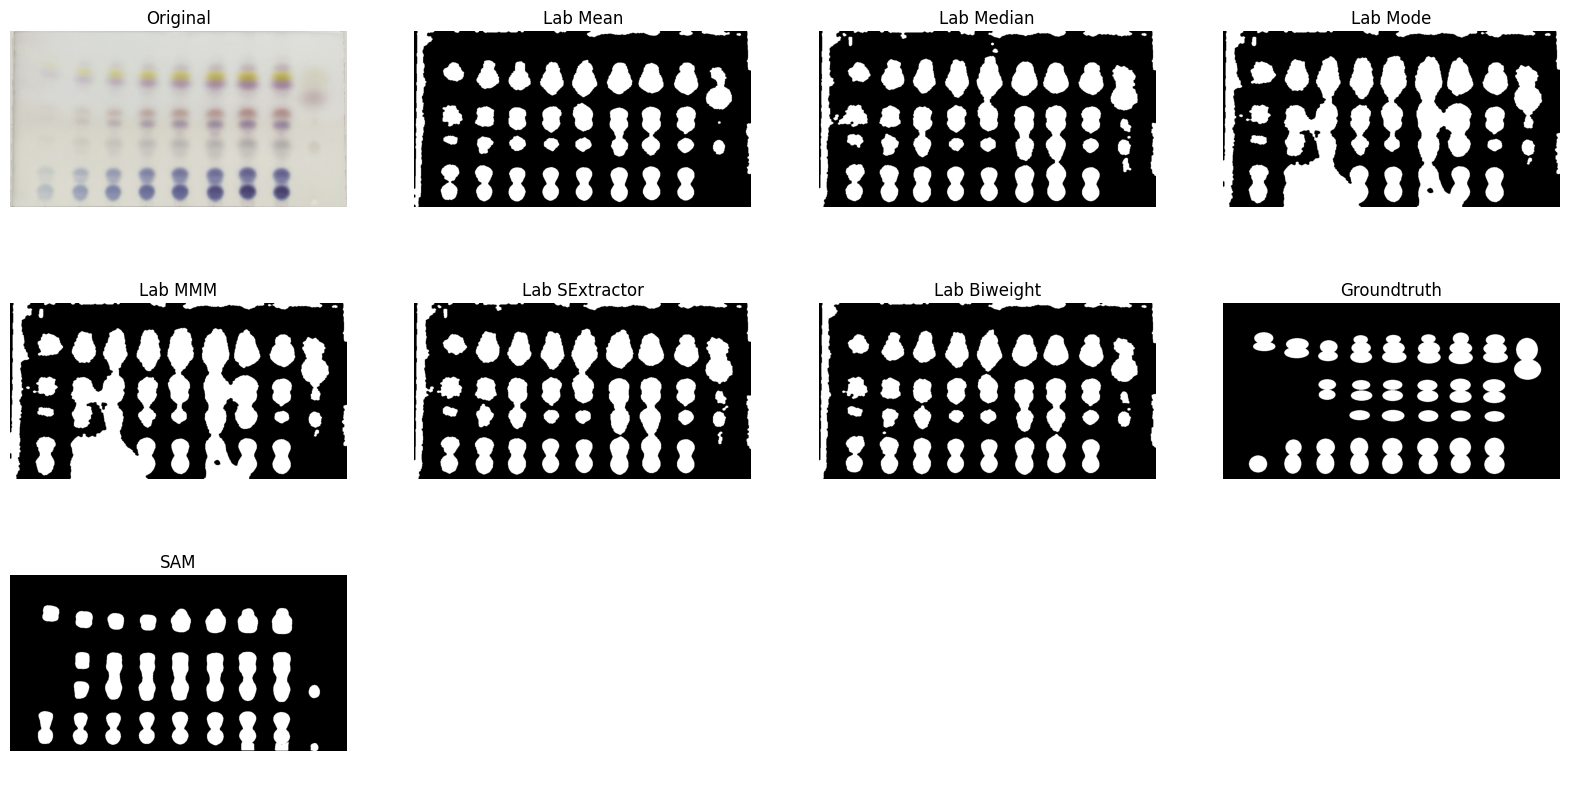

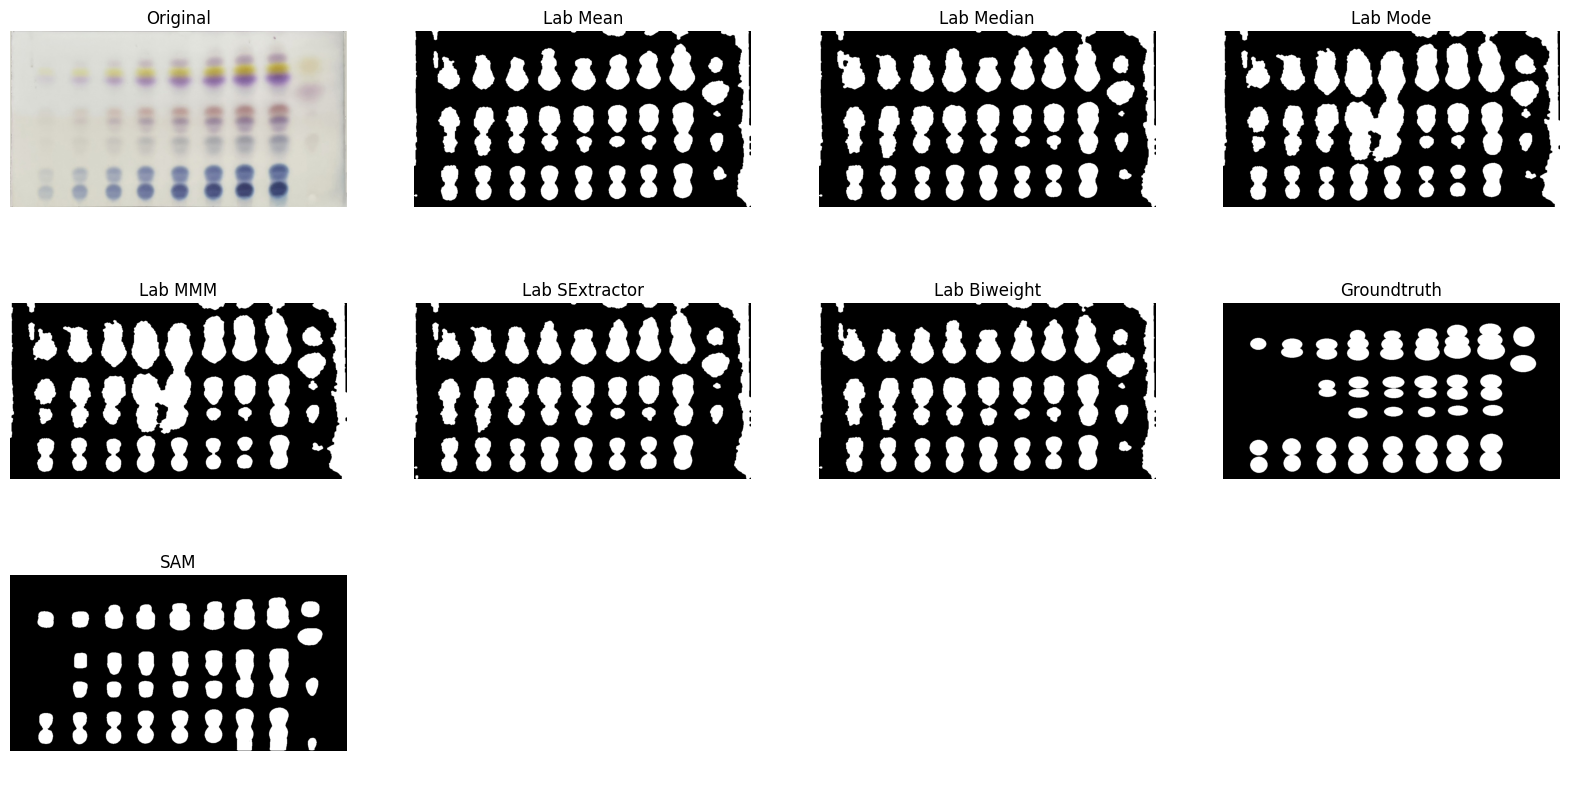

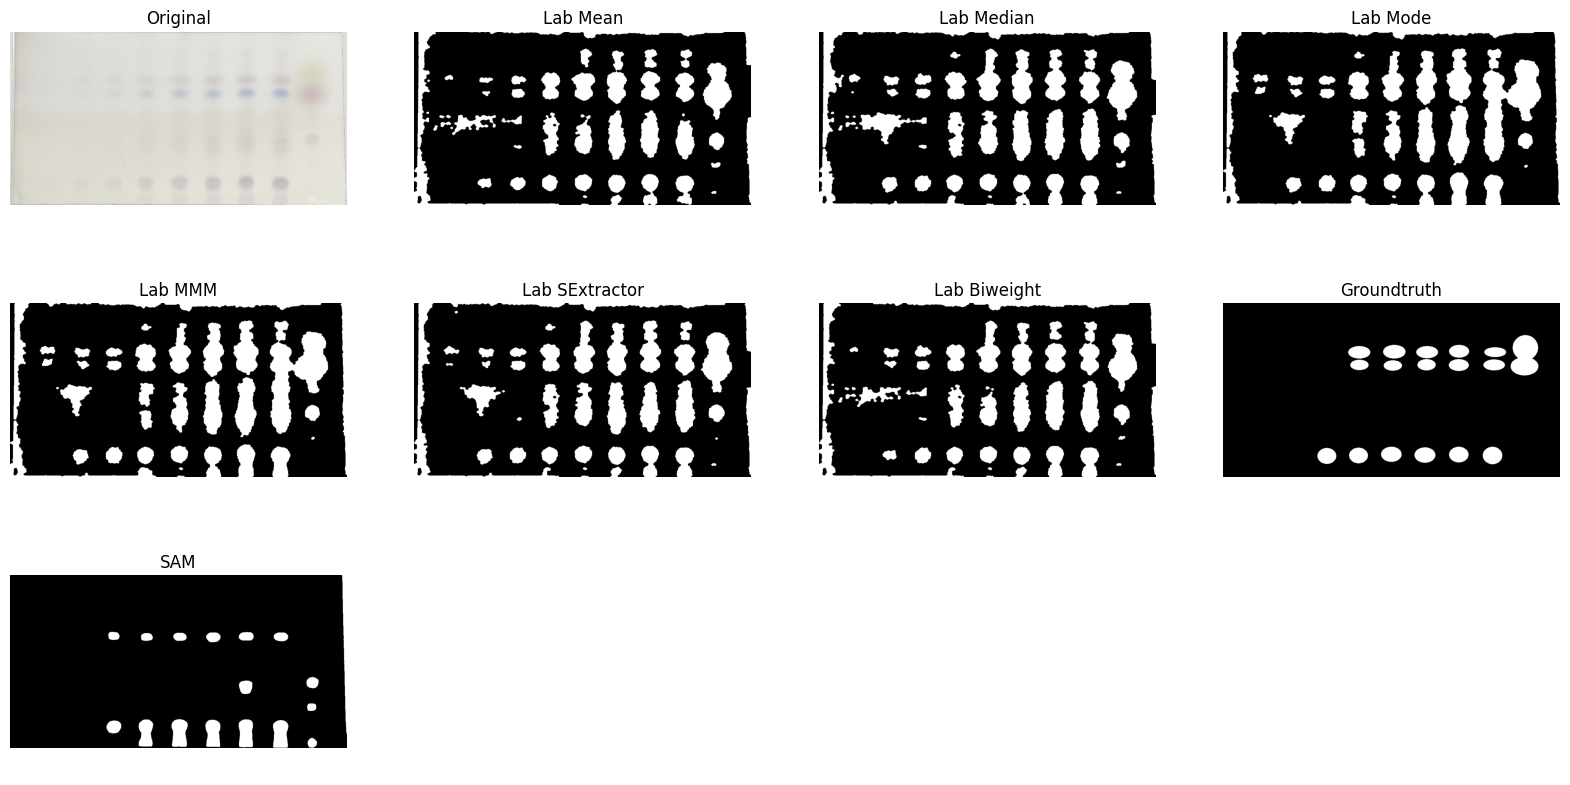

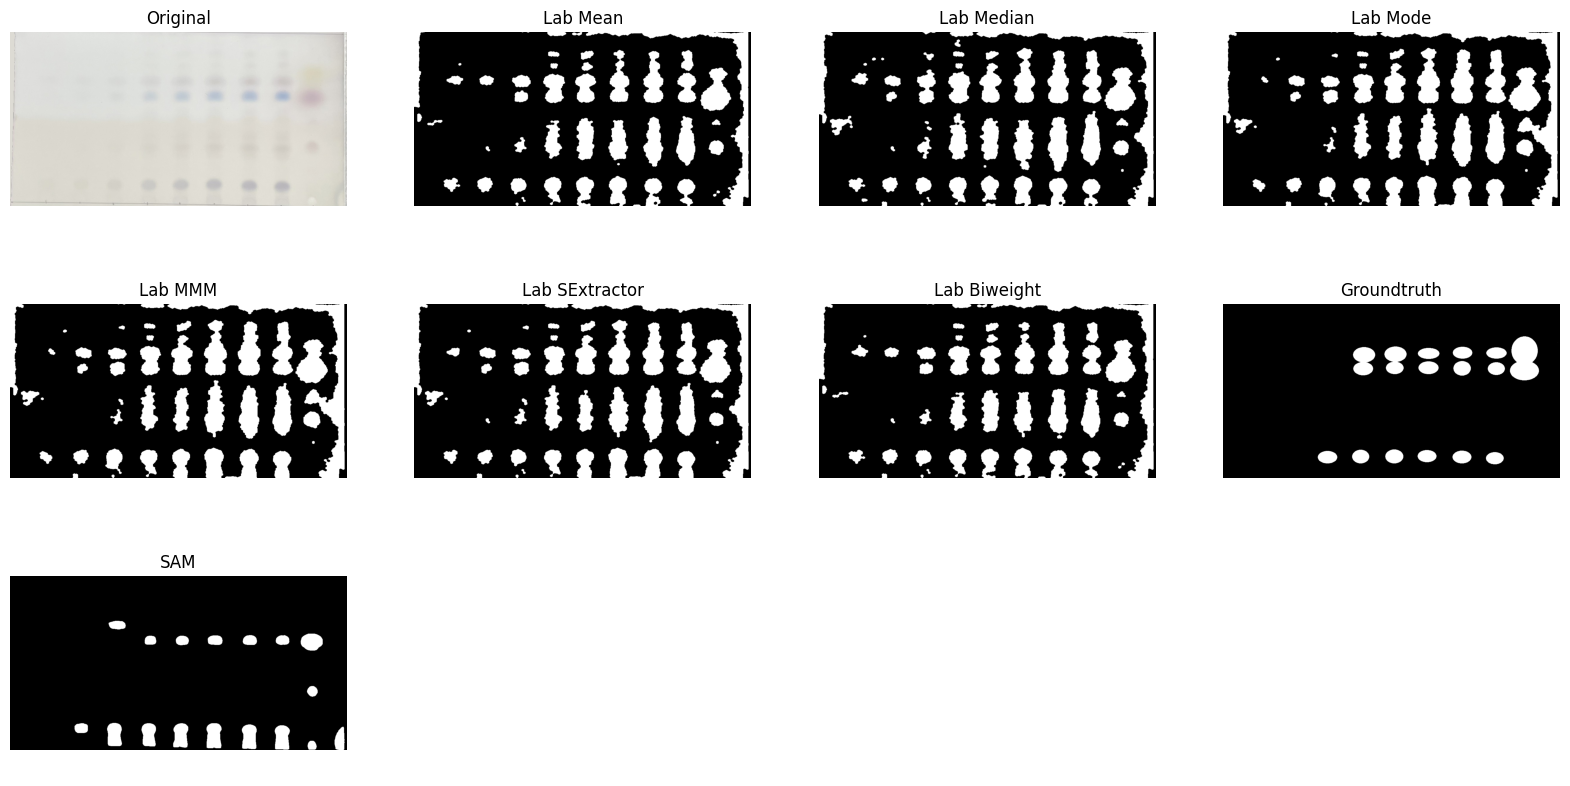

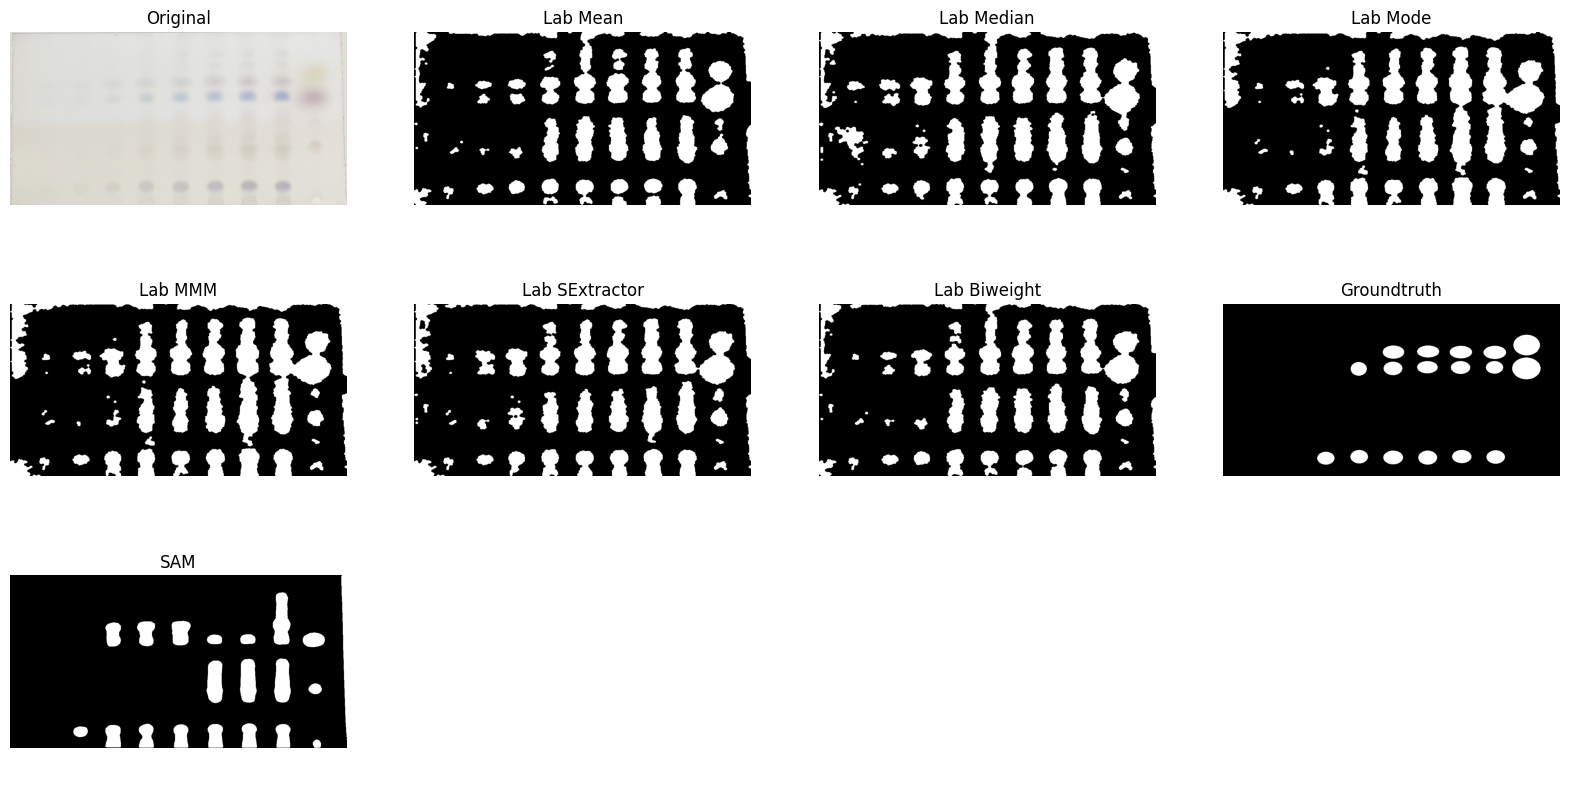

Average SAM: {'precision': 0.765, 'recall': 0.497, 'accuracy': 0.918, 'dice': 0.582, 'iou': 0.431}
Average Lab Mean: {'precision': 0.522, 'recall': 0.936, 'accuracy': 0.883, 'dice': 0.655, 'iou': 0.501}
Average Lab Median: {'precision': 0.437, 'recall': 0.966, 'accuracy': 0.838, 'dice': 0.591, 'iou': 0.429}
Average Lab Mode: {'precision': 0.282, 'recall': 0.978, 'accuracy': 0.63, 'dice': 0.426, 'iou': 0.278}
Average Lab MMM: {'precision': 0.282, 'recall': 0.978, 'accuracy': 0.63, 'dice': 0.426, 'iou': 0.278}
Average Lab SExtractor: {'precision': 0.421, 'recall': 0.97, 'accuracy': 0.829, 'dice': 0.577, 'iou': 0.415}
Average Lab Biweight: {'precision': 0.462, 'recall': 0.96, 'accuracy': 0.853, 'dice': 0.612, 'iou': 0.451}
Highest Precision: 0.765
Highest Recall: 0.978
Highest Accuracy: 0.918
Highest Dice: 0.655
Highest IoU: 0.501


In [86]:
input_dir = get_dir('Input')
groundtruth_dir = get_dir('Output - Groundtruth')
sam_dir = get_dir('Output - SAM')

input_names = os.listdir(input_dir)
groundtruth_names = os.listdir(groundtruth_dir)
groundtruth_names = [name for name in groundtruth_names if 'groundtruth' in name]
sam_names = os.listdir(sam_dir)

total_lab_mean = get_eval_dict()
total_lab_median = get_eval_dict()
total_lab_mode = get_eval_dict()
total_lab_mmm = get_eval_dict()
total_lab_sextractor = get_eval_dict()
total_lab_biweight = get_eval_dict()
total_sam = get_eval_dict()

for input_name, groundtruth_name in zip(input_names, groundtruth_names):
    assert check_name_match(input_name, groundtruth_name)
    
    # Read Image
    image = read_image(input_dir, input_name)
    
    # Create Masks
    mask_lab_mean = create_mask_lab(image, MeanBackground())
    mask_lab_median = create_mask_lab(image, MedianBackground())
    mask_lab_mode = create_mask_lab(image, ModeEstimatorBackground())
    mask_lab_mmm = create_mask_lab(image, MMMBackground())
    mask_lab_sextractor = create_mask_lab(image, SExtractorBackground())
    mask_lab_biweight = create_mask_lab(image, BiweightLocationBackground())
    
    # Apply Masks
    image_lab_mean = apply_mask(image, mask_lab_mean)
    image_lab_median = apply_mask(image, mask_lab_median)
    image_lab_mode = apply_mask(image, mask_lab_mode)
    image_lab_mmm = apply_mask(image, mask_lab_mmm)
    image_lab_sextractor = apply_mask(image, mask_lab_sextractor)
    image_lab_biweight = apply_mask(image, mask_lab_biweight)
    
    # Normalize Masks
    mask_lab_mean = normalize_mask(mask_lab_mean)
    mask_lab_median = normalize_mask(mask_lab_median)
    mask_lab_mode = normalize_mask(mask_lab_mode)
    mask_lab_mmm = normalize_mask(mask_lab_mmm)
    mask_lab_sextractor = normalize_mask(mask_lab_sextractor)
    mask_lab_biweight = normalize_mask(mask_lab_biweight)
    
    # Read Groundtruth
    groundtruth_mask = read_image(groundtruth_dir, groundtruth_name, in_gray=True)
    image_groundtruth = apply_mask(image, groundtruth_mask)
    groundtruth_mask = normalize_mask(groundtruth_mask)
    
    # Read SAM
    sam_name = [name for name in sam_names if check_name_match(input_name, name)][0]
    mask_sam = read_image(sam_dir, sam_name, in_gray=True)
    image_sam = apply_mask(image, mask_sam)
    mask_sam = normalize_mask(mask_sam)
    
    # Get Evaluation
    eval_sam = get_evaluation(groundtruth_mask, mask_sam)
    eval_lab_mean = get_evaluation(groundtruth_mask, mask_lab_mean)
    eval_lab_median = get_evaluation(groundtruth_mask, mask_lab_median)
    eval_lab_mode = get_evaluation(groundtruth_mask, mask_lab_mode)
    eval_lab_mmm = get_evaluation(groundtruth_mask, mask_lab_mmm)
    eval_lab_sextractor = get_evaluation(groundtruth_mask, mask_lab_sextractor)
    eval_lab_biweight = get_evaluation(groundtruth_mask, mask_lab_biweight)
    
    # Update Total Evaluation
    update_total_eval(total_lab_mean, eval_lab_mean)
    update_total_eval(total_lab_median, eval_lab_median)
    update_total_eval(total_lab_mode, eval_lab_mode)
    update_total_eval(total_lab_mmm, eval_lab_mmm)
    update_total_eval(total_lab_sextractor, eval_lab_sextractor)
    update_total_eval(total_lab_biweight, eval_lab_biweight)
    update_total_eval(total_sam, eval_sam)
    
    # # Print Evaluation
    # print(f'Image: {input_name}')
    # print('SAM:', eval_sam)
    # print('Lab Mean:', eval_lab_mean)
    # print('Lab Median:', eval_lab_median)
    # print('Lab Mode:', eval_lab_mode)
    # print('Lab MMM:', eval_lab_mmm)
    # print('Lab SExtractor:', eval_lab_sextractor)
    # print('Lab Biweight:', eval_lab_biweight)
    # print()
    
    # Show Images
    fig, axs = plt.subplots(3, 4, figsize=(20, 10))
    axs = axs.ravel()
    axs[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), axs[0].set_title('Original')
    axs[1].imshow(mask_lab_mean, cmap='gray'), axs[1].set_title('Lab Mean')
    axs[2].imshow(mask_lab_median, cmap='gray'), axs[2].set_title('Lab Median')
    axs[3].imshow(mask_lab_mode, cmap='gray'), axs[3].set_title('Lab Mode')
    axs[4].imshow(mask_lab_mmm, cmap='gray'), axs[4].set_title('Lab MMM')
    axs[5].imshow(mask_lab_sextractor, cmap='gray'), axs[5].set_title('Lab SExtractor')
    axs[6].imshow(mask_lab_biweight, cmap='gray'), axs[6].set_title('Lab Biweight')
    axs[7].imshow(groundtruth_mask, cmap='gray'), axs[7].set_title('Groundtruth')
    axs[8].imshow(mask_sam, cmap='gray'), axs[8].set_title('SAM')
    
    for ax in axs:
        ax.axis('off')
    plt.show()

average_lab_mean = calculate_average_from_total(total_lab_mean, len(input_names))
average_lab_median = calculate_average_from_total(total_lab_median, len(input_names))
average_lab_mode = calculate_average_from_total(total_lab_mode, len(input_names))
average_lab_mmm = calculate_average_from_total(total_lab_mmm, len(input_names))
average_lab_sextractor = calculate_average_from_total(total_lab_sextractor, len(input_names))
average_lab_biweight = calculate_average_from_total(total_lab_biweight, len(input_names))
average_sam = calculate_average_from_total(total_sam, len(input_names))

print('Average SAM:', average_sam)
print('Average Lab Mean:', average_lab_mean)
print('Average Lab Median:', average_lab_median)
print('Average Lab Mode:', average_lab_mode)
print('Average Lab MMM:', average_lab_mmm)
print('Average Lab SExtractor:', average_lab_sextractor)
print('Average Lab Biweight:', average_lab_biweight)
print(f'Highest Precision: {max(average_lab_mean["precision"], average_lab_median["precision"], average_lab_mode["precision"], average_lab_mmm["precision"], average_lab_sextractor["precision"], average_lab_biweight["precision"], average_sam["precision"])}')
print(f'Highest Recall: {max(average_lab_mean["recall"], average_lab_median["recall"], average_lab_mode["recall"], average_lab_mmm["recall"], average_lab_sextractor["recall"], average_lab_biweight["recall"], average_sam["recall"])}')
print(f'Highest Accuracy: {max(average_lab_mean["accuracy"], average_lab_median["accuracy"], average_lab_mode["accuracy"], average_lab_mmm["accuracy"], average_lab_sextractor["accuracy"], average_lab_biweight["accuracy"], average_sam["accuracy"])}')
print(f'Highest Dice: {max(average_lab_mean["dice"], average_lab_median["dice"], average_lab_mode["dice"], average_lab_mmm["dice"], average_lab_sextractor["dice"], average_lab_biweight["dice"], average_sam["dice"])}')
print(f'Highest IoU: {max(average_lab_mean["iou"], average_lab_median["iou"], average_lab_mode["iou"], average_lab_mmm["iou"], average_lab_sextractor["iou"], average_lab_biweight["iou"], average_sam["iou"])}')